In [ ]:
# shots DATA EXTRACTION from StatsBomb repository

import json
import pandas as pd
from tqdm import tqdm
import os

matches_base = "data/matches"
events_base = "data/events"
competitions_file = "data/competitions.json"

competitions = pd.read_json(competitions_file)

all_shots = []

for _, row in tqdm(competitions.iterrows(), total=competitions.shape[0]):
    comp_id = int(row["competition_id"])
    season_id = int(row["season_id"])
    matches_file = f"{matches_base}/{comp_id}/{season_id}.json"

    if not os.path.exists(matches_file):
        continue

    with open(matches_file, encoding="utf-8") as f:
        matches = json.load(f)

    for match in matches:
        match_id = match["match_id"]
        events_file = f"{events_base}/{match_id}.json"
        if not os.path.exists(events_file):
            continue

        with open(events_file, encoding="utf-8") as f:
            events = json.load(f)

        for e in events:
            if e["type"]["name"] == "Shot":
                e["match_id"] = match_id
                e["competition_id"] = comp_id
                e["season_id"] = season_id
                all_shots.append(e)

shots_df = pd.json_normalize(all_shots, sep="_")


100%|██████████| 75/75 [03:46<00:00,  3.01s/it]


In [ ]:
from pathlib import Path
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm

BASE = Path("data")                 
EVENTS_DIR = BASE / "events"        # data/events/<match_id>.json

def read_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def list_event_files(events_dir: Path) -> List[Path]:
    return sorted(events_dir.glob("*.json"))

def extract_shots_and_freeze(events: List[Dict], match_id: int) -> Tuple[List[Dict], List[Dict]]:
    """
    Estrae:
      - shots_rows: 1 riga per tiro con TUTTI i campi raw utili + target is_goal
      - freeze_rows: 1 riga per giocatore nel freeze_frame di quel tiro
    """
    shots_rows, freeze_rows = [], []
    for ev in events:
        if (ev.get("type") or {}).get("name") != "Shot":
            continue

        shot = ev.get("shot", {}) or {}
        outcome_name = (shot.get("outcome") or {}).get("name")
        is_goal = int(outcome_name == "Goal")

        # shot coordinates
        loc = ev.get("location") or [None, None]
        x = loc[0]
        y = loc[1]

        end_loc = shot.get("end_location") or [None, None, None]
        end_x = end_loc[0] if isinstance(end_loc, list) and len(end_loc) >= 2 else None
        end_y = end_loc[1] if isinstance(end_loc, list) and len(end_loc) >= 2 else None

        shots_rows.append({
            "shot_id": ev.get("id"),
            "id": ev.get("id"),
            "index": ev.get("index"),
            "match_id": match_id,
            "competition_id": None,           # populated with external join
            "season_id": None,                # populated with external join
            "period": ev.get("period"),
            "timestamp": ev.get("timestamp"),
            "minute": ev.get("minute"),
            "second": ev.get("second"),
            "duration": ev.get("duration"),
            "possession": ev.get("possession"),
            "related_events": ev.get("related_events"),

            "type_id": (ev.get("type") or {}).get("id"),
            "type_name": (ev.get("type") or {}).get("name"),
            "possession_team_id": (ev.get("possession_team") or {}).get("id"),
            "possession_team_name": (ev.get("possession_team") or {}).get("name"),
            "play_pattern_id": (ev.get("play_pattern") or {}).get("id"),
            "play_pattern_name": (ev.get("play_pattern") or {}).get("name"),
            "team_id": (ev.get("team") or {}).get("id"),
            "team_name": (ev.get("team") or {}).get("name"),
            "player_id": (ev.get("player") or {}).get("id"),
            "player_name": (ev.get("player") or {}).get("name"),
            "position_id": (ev.get("position") or {}).get("id"),
            "position_name": (ev.get("position") or {}).get("name"),

            # shot position
            "location": ev.get("location"),
            "x": x,
            "y": y,

            "shot_statsbomb_xg": shot.get("statsbomb_xg"), 
            "shot_end_location": shot.get("end_location"),
            "end_x": end_x,
            "end_y": end_y,
            "shot_first_time": shot.get("first_time"),
            "shot_technique_id": (shot.get("technique") or {}).get("id"),
            "shot_technique_name": (shot.get("technique") or {}).get("name"),
            "shot_body_part_id": (shot.get("body_part") or {}).get("id"),
            "shot_body_part_name": (shot.get("body_part") or {}).get("name"),
            "shot_type_id": (shot.get("type") or {}).get("id"),
            "shot_type_name": (shot.get("type") or {}).get("name"),
            "shot_outcome_id": (shot.get("outcome") or {}).get("id"),
            "shot_outcome_name": outcome_name,

            "under_pressure": ev.get("under_pressure"),
            "shot_key_pass_id": shot.get("key_pass_id"),
            "shot_aerial_won": shot.get("aerial_won"),
            "shot_one_on_one": shot.get("one_on_one"),
            "shot_deflected": shot.get("deflected"),
            "shot_open_goal": shot.get("open_goal"),
            "shot_saved_off_target": shot.get("saved_off_target"),
            "shot_saved_to_post": shot.get("saved_to_post"),
            "shot_redirect": shot.get("redirect"),
            "shot_follows_dribble": shot.get("follows_dribble"),
            "shot_kick_off": shot.get("kick_off"),
            "off_camera": ev.get("off_camera"),
            "out": ev.get("out"),

            # target 
            "is_goal": is_goal,
        })

        # freeze_frame
        for ff in (shot.get("freeze_frame") or []):
            ff_player = ff.get("player") or {}
            ff_pos = ff.get("position") or {}
            ff_loc = ff.get("location") or [None, None]
            freeze_rows.append({
                "shot_id": ev.get("id"),
                "match_id": match_id,
                "ff_player_id": ff_player.get("id"),
                "ff_player_name": ff_player.get("name"),
                "ff_position": ff_pos.get("name"),
                "teammate": ff.get("teammate"),   # True = shooter teammate
                "ff_x": ff_loc[0],
                "ff_y": ff_loc[1],
            })

    return shots_rows, freeze_rows

all_shots, all_freeze = [], []
for path in tqdm(list_event_files(EVENTS_DIR), desc="Parsing events"):
    match_id = int(path.stem)
    events = read_json(path)
    s_rows, f_rows = extract_shots_and_freeze(events, match_id)
    all_shots.extend(s_rows)
    all_freeze.extend(f_rows)

df_shots  = pd.DataFrame(all_shots).dropna(subset=["x","y"]).reset_index(drop=True)
df_freeze = pd.DataFrame(all_freeze).dropna(subset=["ff_x","ff_y"]).reset_index(drop=True)

print(df_shots.shape, df_freeze.shape)
df_shots.head(3), df_freeze.head(3)


Parsing events: 100%|██████████| 3464/3464 [03:16<00:00, 17.61it/s]


(88023, 55) (1123130, 8)


(                                shot_id                                    id  \
 0  becd7956-ce44-479e-8fc9-16a2d1f1f349  becd7956-ce44-479e-8fc9-16a2d1f1f349   
 1  9107d374-2942-4876-a14f-1b9f86901c15  9107d374-2942-4876-a14f-1b9f86901c15   
 2  ddd194ca-08fb-43d0-87c2-33647f975f9f  ddd194ca-08fb-43d0-87c2-33647f975f9f   
 
    index  match_id competition_id season_id  period     timestamp  minute  \
 0    137     15946           None      None       1  00:02:29.477       2   
 1    262     15946           None      None       1  00:05:39.641       5   
 2    715     15946           None      None       1  00:15:29.059      15   
 
    second  ...  shot_deflected  shot_open_goal shot_saved_off_target  \
 0      29  ...            None            None                  None   
 1      39  ...            None            None                  None   
 2      29  ...            None            None                  None   
 
    shot_saved_to_post shot_redirect  shot_follows_dribble sho

In [ ]:
# Filters only foot shots
mask_foot = df_shots["shot_body_part_name"].isin(["Left Foot","Right Foot"])
foot_shots = df_shots.loc[mask_foot, ["player_id","shot_body_part_name"]].copy()

# Counts for each player
ct = (foot_shots
      .assign(is_left=lambda d: (d["shot_body_part_name"]=="Left Foot").astype(int),
              is_right=lambda d: (d["shot_body_part_name"]=="Right Foot").astype(int))
      .groupby("player_id", as_index=False)[["is_left","is_right"]].sum()
      .rename(columns={"is_left":"n_left","is_right":"n_right"}))

# Bayesian estimate: p_left with Jeffreys prior
a=b=0.5
ct["n"] = ct["n_left"] + ct["n_right"]
ct["p_left"] = (ct["n_left"] + a) / (ct["n"] + a + b)

# Classifies favourite foot
def classify(p):
    if p >= 0.65: return "Left"
    if p <= 0.35: return "Right"
    return "Both"

ct["preferred_foot_inferred"] = ct["p_left"].apply(classify)

# conf: combines imbalance and numerosity (k regulates saturation)
k = 0.15
imbalance = (ct["p_left"] - 0.5).abs()*2   # 0..1
ct["confidence"] = imbalance * (1 - np.exp(-k*ct["n"]))

# Merges on shots dataframe
df_shots = df_shots.merge(ct[["player_id","preferred_foot_inferred","p_left","confidence"]],
                          on="player_id", how="left")

# Creates is_weak_foot for each shot (only if body_part is a foot)
def weak_flag(row):
    bp = row["shot_body_part_name"]
    pf = row["preferred_foot_inferred"]
    if bp not in ("Left Foot","Right Foot"): 
        return np.nan
    if pd.isna(pf): 
        return np.nan
    if pf == "Both":
        return 0  
    return int((bp == "Left Foot" and pf == "Right") or (bp == "Right Foot" and pf == "Left"))

df_shots["is_weak_foot"] = df_shots.apply(weak_flag, axis=1)

# distance from the goal in StatsBomb coordinates (goal center at x=120, y=40)
dx = 120.0 - df_shots["x"].astype(float)
dy = (df_shots["y"].astype(float) - 40.0).abs()
dist_sb = np.sqrt(dx*dx + dy*dy)

# normalizes on [0,1] (diagonal on the half offensive field)
dist_norm = dist_sb / np.sqrt(120.0**2 + 40.0**2)

# interaction: weak foot × distance (uses 0 if is_weak_foot is NaN)
w = df_shots["is_weak_foot"].fillna(0).astype(float)
df_shots["weak_x_distance"] = w * dist_norm



In [ ]:

PITCH_L, PITCH_W = 120.0, 80.0
GOAL_Y_L, GOAL_Y_R = 36.0, 44.0  # posts on y=36 and y=44 in StatsBomb coordinates

def flip_xy(x, y):
    """Flip coordinates (if the team is attacking to the left)."""
    return PITCH_L - x, PITCH_W - y

def need_flip(shot_row):
    """
    Robust heuristic:
    - if we have end_x, use it: if end_x < x ⇒ he was shooting left ⇒ flip
    - otherwise, don't flip (StatsBomb usually has end_x ~ 120 on shots).
    """
    ex = shot_row.get("end_x")
    x  = shot_row.get("x")
    if pd.notna(ex) and pd.notna(x):
        return ex < x
    return False



def shooter_centric_transform(shot_row, freeze_grp):
    """
    Returns:
            pts_opp (N_opp × 2): opponents in the shooter-centric frame.

            pts_tm (N_tm × 2): teammates in the same frame.
            
            posts_sc (2 × 2): coordinates of the posts in the shooter-centric frame.
            
            do_flip: True/False, indicates whether the flip has been done (this is used to return results to the original space).
            
            R: 2×2 matrix of rotation used (it is used to project/report other quantities).
            
            shooter_xy: original shooter's location (it is used to return to the global system if necessary).
            
    Rules:
    1) We ensure attack -> right (flip if necessary)
    2) We translate the shooter to the origin
    3) We rotate so that the CENTER OF THE GOAL is on the +x axis

    """
    
    x, y = float(shot_row["x"]), float(shot_row["y"])
    ex, ey = shot_row.get("end_x"), shot_row.get("end_y")

    do_flip = need_flip(shot_row)
    if do_flip:
        x, y = flip_xy(x, y)
        if pd.notna(ex) and pd.notna(ey):
            ex, ey = flip_xy(ex, ey)

    posts = np.array([[PITCH_L, GOAL_Y_L],
                      [PITCH_L, GOAL_Y_R]], dtype=float)
    if do_flip:
        posts[:,0], posts[:,1] = flip_xy(posts[:,0], posts[:,1])

    ff = freeze_grp[["ff_x","ff_y","teammate"]].copy()
    if do_flip:
        ff[["ff_x","ff_y"]] = ff.apply(lambda r: pd.Series(flip_xy(r.ff_x, r.ff_y)), axis=1)

    shooter_xy = np.array([x, y], dtype=float)

    ff_x = ff["ff_x"].to_numpy() - x
    ff_y = ff["ff_y"].to_numpy() - y
    pts = np.stack([ff_x, ff_y], axis=1)
    posts_t = posts - shooter_xy

    goal_center = posts_t.mean(axis=0)
    theta = -np.arctan2(goal_center[1], goal_center[0])
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])

    pts_sc   = (R @ pts.T).T # players locations in shooter-centric format
    posts_sc = (R @ posts_t.T).T # posts locations in shooter-centric format

    mask_opp = ~freeze_grp["teammate"].astype(bool).to_numpy()
    pts_opp = pts_sc[mask_opp]
    pts_tm  = pts_sc[~mask_opp]

    return pts_opp, pts_tm, posts_sc, do_flip, R, shooter_xy



In [ ]:

"""
Minimal, interpretable function that returns exactly TWO things:
1) pressure_on_shooter  – body-pressure score from defenders, weighting front presence of opponents vs back presence of opponents
2) goal_visible_angle   – open goal angle left by defenders (and its ratio)

Assumptions: shooter at origin (0,0); inputs in SHOOTER-RELATIVE coordinates.

"""
def pressure_and_visible_angle(
    defenders,   # array-like (N,2) positions of defenders relative to shooter
    PL, PR,      # posts coordinates relative to shooter (left and right post)
    *,
    r_def=0.60,      # effective defender body radius for visibility (m)
    r_press=3.0,     # local radius within which pressure is relevant (m)
    lambda_d=6.0,    # distance decay for pressure
    tau_rear=1.0,    # extra decay for out-of-cone defenders
    r_near=1.0,      # override distance: out-of-cone but very close => treat as front (pressure only)
    cone_margin_deg=4.0  # small angular margin to include defenders just outside the posts
):
    """Return a dict with: pressure_on_shooter, goal_visible_angle, goal_visible_ratio.

    PRESSURE (front = goal-cone with near-behind override):
      - Frontali: difensori dentro al cono palo–S–palo.
      - Fuori-cono: pesati meno (exp(-d/tau_rear)).
      - Override: se *fuori-cono ma d <= r_near*, trattalo come frontale (peso pieno).

    GOAL VISIBLE ANGLE:
      Angolo palo–S–palo meno gli intervalli angolari "coperti" dai difensori (dischi r_def).
    """
    # ---- safety ----
    D = np.asarray(defenders, dtype=float) if defenders is not None else np.empty((0,2))
    PL = np.asarray(PL, dtype=float)
    PR = np.asarray(PR, dtype=float)

    # ==========================
    # 1) PRESSURE ON SHOOTER
    # ==========================
    pressure = 0.0
    # calcolo finestra angolare della porta [a,b]
    aL = np.arctan2(PL[1], PL[0])
    aR = np.arctan2(PR[1], PR[0])
    a, b = (aL, aR) if aL < aR else (aR, aL)
    # allarga leggermente il cono per includere chi è appena fuori dai pali
    margin = np.deg2rad(max(cone_margin_deg, 0.0))
    a_expanded = a - margin
    b_expanded = b + margin

    if D.size:
        d = np.linalg.norm(D, axis=1)
        angD = np.arctan2(D[:,1], D[:,0])
        in_front = D[:,0] > 0  # sicurezza basata su orientazione campo
        in_cone = in_front & (angD >= a_expanded) & (angD <= b_expanded)
        # near-behind override: fuori-cono ma molto vicino => trattalo come frontale (solo pressione)
        override = (~in_cone) & (d <= (r_near if r_near is not None else 0.0))
        front_for_pressure = in_cone | override

        # pesi
        w_dist = np.exp(-d / max(lambda_d, 1e-6))
        w_dir = np.ones_like(d)
        # fuori-cono senza override: downweight extra con tau_rear
        out_mask = (~front_for_pressure)
        w_dir[out_mask] = np.exp(-d[out_mask] / max(tau_rear, 1e-6))
        w = w_dist * w_dir
        pressure = float(np.sum(w[d <= (r_press if r_press is not None else np.inf)]))

    # ==================================
    # 2) GOAL VISIBLE ANGLE (radians)
    # ==================================
    # base angle
    vL = PL
    vR = PR
    def _angle(u, v):
        nu, nv = np.linalg.norm(u), np.linalg.norm(v)
        if nu == 0 or nv == 0:
            return 0.0
        c = np.clip((u @ v) / (nu*nv), -1.0, 1.0)
        return float(np.arccos(c))
    base = _angle(vL, vR)
    
    theta_free_center = None
    cos_t = 0.0
    sin_t = 0.0
    free_arcs = []

    # no defenders => fully visible
    if D.size == 0 or base <= 0:
        
        theta_free_center = (a + b) / 2.0 if base > 0 else None
        cos_t = float(np.cos(theta_free_center)) if theta_free_center is not None else 0.0
        sin_t = float(np.sin(theta_free_center)) if theta_free_center is not None else 0.0
        
        
        return {
            "base_angle" : base,
            "pressure_on_shooter": pressure,
            "goal_visible_angle": base,
            "goal_visible_ratio": 1.0 if base > 0 else 0.0,
            "theta_free_center": None if theta_free_center is None else float(theta_free_center),
            "cos_theta_free_center": cos_t,
            "sin_theta_free_center": sin_t,
            "free_arcs": [(float(a), float(b))] if base > 0 else [],
        }

    # defender angular intervals (disc radius r_def) intersected with [a,b]
    intervals = []
    for p in D:
        v = p
        dist = np.linalg.norm(v)
        if dist <= 1e-9:
            # on shooter — occludes everything
            return {
                "base_angle" : base,
                "pressure_on_shooter": pressure,
                "goal_visible_angle": 0.0,
                "goal_visible_ratio": 0.0,
                "theta_free_center": None,
                "cos_theta_free_center": 0.0,
                "sin_theta_free_center": 0.0,
                "free_arcs": [],
            }
        phi = np.arctan2(v[1], v[0])
        half = float(np.arcsin(np.clip(r_def / max(dist, r_def), -1.0, 1.0)))
        lo, hi = phi - half, phi + half
        # intersect with [a,b]
        lo2, hi2 = max(lo, a), min(hi, b)
        if lo2 < hi2:
            intervals.append((lo2, hi2))

    if not intervals:
        vis = base
    else:
        intervals.sort()
        merged = [intervals[0]]
        for lo, hi in intervals[1:]:
            L0, H0 = merged[-1]
            if lo <= H0:
                merged[-1] = (L0, max(H0, hi))
            else:
                merged.append((lo, hi))
        blocked = sum(hi - lo for lo, hi in merged)
        vis = max(0.0, base - blocked)
        
        free_arcs = []
        cursor = a
        for lo, hi in merged:
            if lo > cursor:
                free_arcs.append((cursor, lo))
            cursor = max(cursor, hi)
        if cursor < b:
            free_arcs.append((cursor, b))

        if free_arcs:
            lo_best, hi_best = max(free_arcs, key=lambda ab: ab[1] - ab[0])
            theta_free_center = 0.5 * (lo_best + hi_best)
            cos_t = float(np.cos(theta_free_center))
            sin_t = float(np.sin(theta_free_center))
        
        free_arcs = []
        cursor = a
        for lo, hi in merged:
            if lo > cursor:
                free_arcs.append((cursor, lo))
            cursor = max(cursor, hi)
        if cursor < b:
            free_arcs.append((cursor, b))

        if free_arcs:
            lo_best, hi_best = max(free_arcs, key=lambda ab: ab[1] - ab[0])
            theta_free_center = 0.5 * (lo_best + hi_best)
            cos_t = float(np.cos(theta_free_center))
            sin_t = float(np.sin(theta_free_center))
        else:
            theta_free_center = None
            cos_t = 0.0
            sin_t = 0.0


    return {
        "base_angle" : base,
        "pressure_on_shooter": pressure,
        "goal_visible_angle": float(vis),
        "goal_visible_ratio": float(vis / base) if base > 0 else 0.0,
        "theta_free_center": None if theta_free_center is None else float(theta_free_center),
        "cos_theta_free_center": cos_t,
        "sin_theta_free_center": sin_t,
        "free_arcs": [(float(lo), float(hi)) for lo, hi in free_arcs],
    }


def pressure_local_centered(D, theta_center, r_press=6.0, lambda_d=1.2, sigma_ang=np.deg2rad(35)):
    if D.size == 0:
        return 0.0, 0, 0, np.nan
    D = np.asarray(D, dtype=float)
    dx, dy = D[:,0], D[:,1]
    dist = np.hypot(dx, dy)
    in_front = dx > 0.0

    angD = np.arctan2(dy, dx)
    dphi = (angD - theta_center + np.pi) % (2*np.pi) - np.pi

    mask = in_front & (dist <= r_press)
    w = np.exp(-dist / max(lambda_d, 1e-9)) * np.exp(-0.5 * (dphi / max(sigma_ang, 1e-9))**2)
    w[~mask] = 0.0

    pressure_local = float(np.sum(w))
    n_close_1m = int(np.sum((dist <= 1.0) & in_front))
    n_close_2m = int(np.sum((dist <= 2.0) & in_front))
    min_dist_front = float(np.min(dist[in_front])) if np.any(in_front) else np.nan
    return pressure_local, n_close_1m, n_close_2m, min_dist_front



def cone_metrics_simple(pts, posts_sc, r_los=0.9):
    """
    Cono = intervallo angolare tra i vettori verso i due pali (x>0).
    Ritorna:
      - n_in_cone: # punti nel cono (x>0, angolo tra pali)
      - cone_density: somma 1/(1+dist) sui punti nel cono
    """
    # vectors towards poles (already in the rotated frame)
    vL, vR = posts_sc[0], posts_sc[1]
    # ensures that vL is the "lowest" angularly
    ang = np.sort([np.arctan2(vL[1], vL[0]), np.arctan2(vR[1], vR[0])])
    aL, aR = ang[0], ang[1]

    if pts.size == 0:
        return {"n_in_cone": 0, "cone_density": 0.0}

    ang_pts = np.arctan2(pts[:,1], pts[:,0])
    in_front = pts[:,0] > 0
    in_cone = in_front & (ang_pts >= aL) & (ang_pts <= aR)

    d = np.linalg.norm(pts[in_cone], axis=1)
    cone_density = float(np.sum(1.0/(1.0 + d))) if d.size else 0.0

    return {"n_in_cone": int(in_cone.sum()), "cone_density": cone_density}


In [ ]:
# --- GK FEATURES -------------------------------------------------------------

def find_opp_gk_row(freeze_grp: pd.DataFrame) -> pd.Series | None:
    """Ritorna la riga dell'avversario con ruolo 'Goalkeeper' (se presente)."""
    mask = (~freeze_grp["teammate"].astype(bool)) & (
        freeze_grp["ff_position"].fillna("").str.contains("Goalkeeper", case=False)
    )
    gk_rows = freeze_grp[mask]
    if len(gk_rows) == 0:
        return None
    return gk_rows.iloc[0]

def transform_point_to_shooter_frame(px, py, shot_row, do_flip, R, shooter_xy):
    """Applica flip/traslazione/rotazione al singolo punto."""
    if do_flip:
        px, py = PITCH_L - px, PITCH_W - py
    # translates
    v = np.array([px - shooter_xy[0], py - shooter_xy[1]], dtype=float)
    # rotates
    return (R @ v)

def gk_features(shot_row, freeze_grp, posts_sc, do_flip, R, shooter_xy):
    """
    Ritorna:
      - gk_offset_from_center: distanza GK - centro porta
      - gk_dist_to_shotline: distanza perpendicolare GK dalla shotline (y=0 nel frame ruotato)
    Se GK assente: np.nan.
    """
    gk_row = find_opp_gk_row(freeze_grp)
    if gk_row is None:
        return {"gk_offset_from_center": np.nan, "gk_dist_to_shotline": np.nan}

    gk_sc = transform_point_to_shooter_frame(
        float(gk_row.ff_x), float(gk_row.ff_y),
        shot_row, do_flip, R, shooter_xy
    )

    goal_center_sc = posts_sc.mean(axis=0)
    off_center = float(np.linalg.norm(gk_sc - goal_center_sc))
    dist_shotline = float(abs(gk_sc[1]))  # shotline = x axis in the rotated frame

    return {"gk_offset_from_center": off_center, "gk_dist_to_shotline": dist_shotline}


In [ ]:

# DataFrame Construction (Minimal Set)
# ---------------------------------------------
# Replaces the feature creation loop with the minimal version:
# - pressure_on_shooter
# - goal_visible_angle / goal_visible_ratio
# - (opt.) kdist_min as a simple anchor
# - Compact GK features (lateral offset, depth, covered angle)

# I assume the following are available:
# - shooter_centric_transform(shot, freeze_grp) -> (pts_opp, pts_tm, posts_sc, do_flip, R, shooter_xy)
# - pressure_and_visible_angle(defenders, PL, PR, ...)
# - gk_features(shot, freeze_grp, posts_sc, do_flip, R, shooter_xy) -> dict with
# {"gk_offset_from_center", "gk_depth", "gk_covered_angle"}

feat_rows = []
g = df_freeze.groupby("shot_id", sort=False)

for _, shot in df_shots.iterrows():
    sid = shot["shot_id"]
    if sid not in g.groups:
        continue
    freeze_grp = g.get_group(sid)

    # shooter-centric transformation
    pts_opp, pts_tm, posts_sc, do_flip, R, shooter_xy = shooter_centric_transform(shot, freeze_grp)
    PL, PR = posts_sc[0], posts_sc[1]

    # Pression + goal_visible_angle
    pav = pressure_and_visible_angle(
        defenders=pts_opp,
        PL=PL, PR=PR,
        r_def=0.60, r_press=3.0, lambda_d=6.0, tau_rear=1.0,
        r_near=1.0, cone_margin_deg=4.0
    )

    # distance of the closest opponent
    kdist_min = float(np.linalg.norm(pts_opp, axis=1).min()) if pts_opp.size else np.nan

    # GK compact features
    gk_feat = gk_features(shot, freeze_grp, posts_sc, do_flip, R, shooter_xy)
    
    # local pressure centered on the free direction
    theta_center = pav["theta_free_center"]
    if theta_center is None:
        theta_center = 0.5 * (np.arctan2(PL[1], PL[0]) + np.arctan2(PR[1], PR[0]))
    pl, n1, n2, dmin = pressure_local_centered(pts_opp, theta_center)

    feat_rows.append({
        "shot_id": sid,
        # New core features
        "goal_base_angle" : pav["base_angle"],
        "goal_visible_angle":  pav["goal_visible_angle"],
        "goal_visible_ratio":  pav["goal_visible_ratio"],
        "pressure_local": pl,
        "n_close_1m" : n1,
        "n_close_2m" : n2,
        "dmin" : dmin,
        #"opp_kdist_min": kdist_min,
        # GK
        "gk_offset_from_center": gk_feat["gk_offset_from_center"], 
        "gk_dist_to_shotline": gk_feat["gk_dist_to_shotline"],
    })
    

df_graph_ext = pd.DataFrame(feat_rows)
df_graph_ext.head()



,shot_id,goal_base_angle,goal_visible_angle,goal_visible_ratio,pressure_local,n_close_1m,n_close_2m,dmin,gk_offset_from_center,gk_dist_to_shotline
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,0.296402,1.606765e-01,5.420898e-01,0.128382,0,1,1.216553,6.603787,0.158590
1,9107d374-2942-4876-a14f-1b9f86901c15,0.232420,1.271653e-01,5.471348e-01,0.005046,0,0,4.976947,3.511410,0.255613
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,0.290500,2.775558e-16,9.554425e-16,0.277599,0,1,1.676305,2.640076,0.604203
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,0.705452,5.624831e-01,7.973373e-01,0.064544,1,1,0.905539,2.600000,0.797237
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,0.259971,1.290497e-01,4.963997e-01,0.087071,0,0,2.773085,3.538361,0.255511


In [ ]:

# is_acrobatic (difficult/atypical shot techniques) ---
acrobatic_set = {"Backheel", "Overhead Kick", "Bicycle Kick", "Scorpion Kick", "Half Volley"}
df_shots["is_acrobatic"] = df_shots["shot_technique_name"].isin(acrobatic_set).astype(int)

df_shots["play_context"] = np.select(
    [
        df_shots["play_pattern_name"].isin(["From Corner", "From Free Kick", "From Kick Off", "From Throw In"]),
        df_shots["play_pattern_name"].isin(["From Counter"]),
    ],
    ["set_piece", "counter"],
    default="open_play"
)

df_shots.head()

,shot_id,id,index,match_id,competition_id,season_id,period,timestamp,minute,second,...,off_camera,out,is_goal,preferred_foot_inferred,p_left,confidence,is_weak_foot,weak_x_distance,is_acrobatic,play_context
0,becd7956-ce44-479e-8fc9-16a2d1f1f349,becd7956-ce44-479e-8fc9-16a2d1f1f349,137,15946,None,None,1,00:02:29.477,2,29,...,None,None,0,Left,0.883360,0.766719,1.0,0.122132,1,set_piece
1,9107d374-2942-4876-a14f-1b9f86901c15,9107d374-2942-4876-a14f-1b9f86901c15,262,15946,None,None,1,00:05:39.641,5,39,...,None,None,0,Left,0.791262,0.582524,0.0,0.000000,0,open_play
2,ddd194ca-08fb-43d0-87c2-33647f975f9f,ddd194ca-08fb-43d0-87c2-33647f975f9f,715,15946,None,None,1,00:15:29.059,15,29,...,None,None,0,Left,0.883360,0.766719,0.0,0.000000,0,open_play
3,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,86596ddb-d824-4e5e-b18c-b4442e9ce7cf,743,15946,None,None,1,00:16:20.072,16,20,...,None,None,0,Right,0.250000,0.263817,NaN,0.000000,0,open_play
4,3ed2b107-be17-42d5-9d1b-25006a0e55cb,3ed2b107-be17-42d5-9d1b-25006a0e55cb,802,15946,None,None,1,00:18:16.362,18,16,...,None,None,0,Right,0.269882,0.460237,0.0,0.000000,0,set_piece


In [ ]:
# merge the two dataset on common columns
df_model = df_shots.merge(df_graph_ext, on="shot_id", how="left")

print(df_model.shape)
df_model.columns

(88023, 71)


Index(['shot_id', 'id', 'index', 'match_id', 'competition_id', 'season_id',
       'period', 'timestamp', 'minute', 'second', 'duration', 'possession',
       'related_events', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'player_id', 'player_name', 'position_id',
       'position_name', 'location', 'x', 'y', 'shot_statsbomb_xg',
       'shot_end_location', 'end_x', 'end_y', 'shot_first_time',
       'shot_technique_id', 'shot_technique_name', 'shot_body_part_id',
       'shot_body_part_name', 'shot_type_id', 'shot_type_name',
       'shot_outcome_id', 'shot_outcome_name', 'under_pressure',
       'shot_key_pass_id', 'shot_aerial_won', 'shot_one_on_one',
       'shot_deflected', 'shot_open_goal', 'shot_saved_off_target',
       'shot_saved_to_post', 'shot_redirect', 'shot_follows_dribble',
       'shot_kick_off', 'off_camera', 'out', 'is_goal',
       'preferred_foot_inferred', 'p_lef

In [ ]:
# === Key-Pass features===
# Scans event JSON and indexes ONLY passes with id used in df_shots/df_model as a key_pass

import os, json, math, glob
import numpy as np
import pandas as pd

BASE = Path("data")                 
EVENTS_DIR = BASE / "events"        # data/events

# Get pass ids from joinale
need_ids = (
    pd.concat([
        df_shots.get("shot_key_pass_id", pd.Series(dtype="string")),
        df_model.get("shot_key_pass_id", pd.Series(dtype="string")),
    ], ignore_index=True)
    .dropna().astype(str).unique().tolist()
)
need = set(need_ids)
print("key_pass_id richiesti:", len(need))

if not need:
    print("Nessun shot_key_pass_id nel dataset. Nulla da fare.")
else:
    # Index {pass_id: feature_dict}
    kp_index = {}
    files = glob.glob(os.path.join(EVENTS_DIR, "*.json"))
    print("Event files trovati:", len(files))

    def _xy(v):
        if isinstance(v, (list, tuple)) and len(v) >= 2:
            return float(v[0]), float(v[1])
        return (np.nan, np.nan)

    for i, fp in enumerate(files, 1):
        try:
            with open(fp, "r", encoding="utf-8") as f:
                events = json.load(f)
        except Exception as e:
            # problematic file : skip
            continue

        for ev in events:
            if ev.get("type", {}).get("name") != "Pass":
                continue
            pid = str(ev.get("id"))
            if pid not in need:
                continue  # index only the needed ones

            # useful fields + robust fallbacks
            play_pat = ev.get("play_pattern", {}).get("name")
            duration = ev.get("duration", None)
            length   = ev.get("pass", {}).get("length", None)
            angle    = ev.get("pass", {}).get("angle", None)
            height_n = ev.get("pass", {}).get("height", {}).get("name")

            sx, sy = _xy(ev.get("location"))
            ex, ey = _xy(ev.get("pass", {}).get("end_location"))

            # verticality towards the goal (x+): cos(angle) in [-1,1]
            vert = None
            try:
                vert = math.cos(float(angle)) if angle is not None else None
            except Exception:
                vert = None

            # speed (m/s) with cap
            spd = None
            try:
                spd = (float(length) / float(duration)) if duration not in (None, 0) else None
                if spd is not None:
                    spd = min(spd, 40.0)
            except Exception:
                spd = None

            # to box (StatsBomb coordinates: x>=102 & 18<=y<=62)
            to_box = int((ex is not None) and (ey is not None) and (ex >= 102.0) and (18.0 <= ey <= 62.0))

            # from Set Piece
            from_sp = int(play_pat in ["From Free Kick", "From Corner", "From Throw In"])

            kp_index[pid] = {
                "kp_length": length,
                "kp_speed": spd,
                "kp_verticality": vert,
                "kp_forward": int(vert is not None and vert > 0),
                "kp_to_box": to_box,
                "kp_from_set_piece": from_sp,
            }

            # early stop if everything is found correctly
            if len(kp_index) == len(need):
                break
        if len(kp_index) == len(need):
            break

    print("Key-passes indicizzati:", len(kp_index))

    # Apply to df_model
    if len(kp_index) > 0:
        kp_df = pd.DataFrame.from_dict(kp_index, orient="index")
        kp_df.index.name = "shot_key_pass_id"
        kp_df.reset_index(inplace=True)

        # Transformation to string needed for the join
        df_model["shot_key_pass_id"] = df_model["shot_key_pass_id"].astype(str)
        kp_df["shot_key_pass_id"]    = kp_df["shot_key_pass_id"].astype(str)

        df_model = df_model.merge(kp_df, on="shot_key_pass_id", how="left")

        df_model["is_assisted"] = df_model["shot_key_pass_id"].notna().astype("Int64")

        # for binary columns, fill with 0; for continuous columns, leave NaN (pipeline input if needed)
        for c in ["kp_forward","kp_to_box","kp_from_set_piece"]:
            if c in df_model: df_model[c] = df_model[c].fillna(0).astype("Int64")

        # coverage check
        ok_rate = float((df_model["shot_key_pass_id"].notna() & df_model["kp_length"].notna()).mean())
        print("assist join ok rate:", ok_rate)
    else:
        print("No keypass found in the scanned JSON. Check EVENTS_DIR or covered matches.")


key_pass_id richiesti: 62012
Event files trovati: 3464
Key-passes indicizzati: 62012
assist join ok rate: 0.7044976881042455


In [ ]:
# === Calculating the match result at shooting timestamp ===

import os, json, glob
import pandas as pd
import numpy as np

# === PATH open-data ===
MATCHES_DIR = "data/matches"   # es: ".../open-data/data/matches"
EVENTS_DIR  = "data/events"    # es: ".../open-data/data/events"

# === 1) match_id -> (home_team_id, away_team_id)
rows = []
for fp in glob.glob(os.path.join(MATCHES_DIR, "*", "*.json")):
    with open(fp, "r", encoding="utf-8") as f:
        matches = json.load(f)
    for m in matches:
        home = m.get("home_team", {})
        away = m.get("away_team", {})
        rows.append({
            "match_id": int(m["match_id"]),
            "home_team_id": int(home.get("home_team_id", home.get("id"))),
            "away_team_id": int(away.get("away_team_id", away.get("id"))),
        })
df_matches = pd.DataFrame(rows).drop_duplicates("match_id")

def _period_offset_seconds(p: int) -> int:
    # 1: 0..45', 2: 45..90', 3: 90..105', 4: 105..120'; 5 (shootout) escluso
    return {1:0, 2:45*60, 3:90*60, 4:105*60}.get(int(p), 0)

# === 2) for each match: scrolls through events and finds the score BEFORE each shot
snaps = []
for ev_fp in glob.glob(os.path.join(EVENTS_DIR, "*.json")):
    match_id = int(os.path.basename(ev_fp).replace(".json",""))
    try:
        with open(ev_fp, "r", encoding="utf-8") as f:
            events = json.load(f)
    except Exception:
        continue

    # finds home/away team id
    rowm = df_matches.loc[df_matches["match_id"] == match_id]
    if rowm.empty:
        # fallback (raro): prendi i primi 2 team id presenti nel file
        team_ids = [e.get("team",{}).get("id") for e in events if "team" in e]
        uniq = [int(t) for t in pd.Series(team_ids).dropna().unique().tolist()[:2]]
        if len(uniq) < 2: 
            continue
        home_id, away_id = uniq[0], uniq[1]
    else:
        home_id, away_id = int(rowm.iloc[0]["home_team_id"]), int(rowm.iloc[0]["away_team_id"])

    score_home = 0
    score_away = 0

    for ev in events:
        tname = ev.get("type",{}).get("name")
        period = int(ev.get("period", 1))
        if period == 5:   # excludes penalties' sudden death
            continue

        team_id = ev.get("team",{}).get("id")
        minute  = int(ev.get("minute", 0))
        second  = float(ev.get("second", 0.0))
        abs_t   = _period_offset_seconds(period) + minute*60 + second

        if tname == "Shot":
            shot_id = str(ev.get("id"))
            is_home = int(team_id == home_id)

            shooter_goals = score_home if is_home else score_away
            opp_goals     = score_away if is_home else score_home
            diff = shooter_goals - opp_goals
            state = "level" if diff == 0 else ("leading" if diff > 0 else "trailing")

            snaps.append({
                "shot_event_id": shot_id,
                "match_id": match_id,
                "team_id": team_id,
                "is_home_shot": is_home,
                "score_home_before": score_home,
                "score_away_before": score_away,
                "score_diff_shooter": diff,
                "score_state_shooter": state,
                "abs_time": abs_t,
            })

            # after the snapshot, if it's a goal, updates the score
            outcome = ev.get("shot",{}).get("outcome",{}).get("name")
            if outcome == "Goal":
                if team_id == home_id: score_home += 1
                elif team_id == away_id: score_away += 1

        elif tname == "Own Goal For":
            # own goal in favor of the event team
            if team_id == home_id: score_home += 1
            elif team_id == away_id: score_away += 1

df_score = pd.DataFrame(snaps)

# === 3) Merge on df_model ===

score_cols = ["is_home_shot","score_home_before","score_away_before","score_diff_shooter","score_state_shooter","match_id"]
if "shot__id" in df_model.columns:
    df_model = df_model.merge(df_score[["shot_event_id"] + score_cols], on="shot_event_id", how="left")
elif "id" in df_model.columns:
    df_model = df_model.merge(df_score.rename(columns={"shot_event_id":"id"})[["id"] + score_cols], on="id", how="left")
elif set(score_cols).issubset(df_shots.columns) and len(df_shots) == len(df_model):
    # fallback: inherits from df_shots by index (valid if df_model derives directly from df_shots)
    df_model = df_model.join(df_shots[score_cols])

# categorizes score diff in useful buckets
df_model["score_state_shooter"] = pd.Categorical(
    df_model["score_state_shooter"],
    categories=["trailing","level","leading"],
    ordered=True
)
df_model["score_diff_bucket"] = pd.cut(
    df_model["score_diff_shooter"],
    bins=[-10, -2, -1, 0, 1, 2, 10],
    labels=["<=-2","-1","0","+1","+2", ">=+2"],
    include_lowest=True
)

# coverage check
cov = float(df_model["is_home_shot"].notna().mean())
print(f"Coverage nuove feature in df_model: {cov:.3f}")


Coverage nuove feature in df_model: 0.996


In [ ]:
# === Final shooter direction (cosine towards the goal) with dynamic logic ===
import os, json, glob, math
import numpy as np
import pandas as pd

EVENTS_DIR = "data/events"

# Constants/helpers
SX, SY = 105.0/120.0, 68.0/80.0           # meter conversion
GOAL = (120.0, 40.0)                       # center of the opponent's goal in StatsBomb data
WIN_SEC = 6.0                              # window for anchor on-ball
REB_SEC = 3.0                              # window for rebound
ANCHOR_TYPES = {"Carry", "Dribble", "Ball Receipt", "Ball Receipt*"}  # eventi on-ball

def _xy(v):
    if isinstance(v,(list,tuple)) and len(v)>=2: return float(v[0]), float(v[1])
    return (np.nan, np.nan)

def _poff(p:int) -> int:
    return {1:0, 2:45*60, 3:90*60, 4:105*60}.get(int(p), 0)

def _dist_m(a,b):
    dx, dy = (a[0]-b[0])*SX, (a[1]-b[1])*SY
    return math.hypot(dx, dy)

def _approach_cos(move_from, move_to, ref_point_for_goal=None):
    """
    coseno tra vettore di movimento (from->to) e direzione (from->goal_center).
    ref_point_for_goal: se None, usa 'from' come origine per il vettore verso porta.
    """
    fx, fy = move_from; tx, ty = move_to
    mv = np.array([(tx - fx)*SX, (ty - fy)*SY], float)
    gx, gy = ref_point_for_goal if ref_point_for_goal is not None else move_from
    gv = np.array([(GOAL[0]-gx)*SX, (GOAL[1]-gy)*SY], float)
    n1, n2 = np.linalg.norm(mv), np.linalg.norm(gv)
    if n1 == 0 or n2 == 0 or np.isnan(n1) or np.isnan(n2):
        return np.nan
    return float(np.dot(mv, gv) / (n1*n2))

rows = []

# on all match events
for fp in glob.glob(os.path.join(EVENTS_DIR, "*.json")):
    try:
        with open(fp, "r", encoding="utf-8") as f:
            evs = json.load(f)
    except Exception:
        continue

    # index Pass by id (used for first-time + assist)
    pass_by_id = {}
    for ev in evs:
        if ev.get("type",{}).get("name") == "Pass":
            pid = str(ev.get("id"))
            ex, ey = _xy(ev.get("pass",{}).get("end_location"))
            p = int(ev.get("period",1))
            t0 = _poff(p) + int(ev.get("minute",0))*60 + float(ev.get("second",0.0))
            dur = ev.get("duration", None)
            t_end = (t0 + float(dur)) if dur not in (None,0) else t0
            pass_by_id[pid] = {"end": (ex, ey), "t_end": t_end}

    # states for anchor on-ball and rebound
    last_onball = {}   # (player_id, possession) -> dict(time, loc, type, end_loc)
    last_shot   = {}   # player_id -> dict(time, loc)

    for ev in evs:
        tname = ev.get("type",{}).get("name")
        period = int(ev.get("period",1))
        if period == 5:  # exclude penalties s.d.
            continue

        team_id   = ev.get("team",{}).get("id")
        player_id = ev.get("player",{}).get("id")
        poss      = ev.get("possession", None)
        loc       = _xy(ev.get("location"))
        minute    = int(ev.get("minute",0))
        second    = float(ev.get("second",0.0))
        t_abs     = _poff(period) + minute*60 + second

        # update anchor on-ball
        if tname in ANCHOR_TYPES and player_id is not None and poss is not None:
            rec = {"time": t_abs, "loc": loc, "type": tname, "end_loc": None}
            if tname == "Carry":
                rec["end_loc"] = _xy(ev.get("carry",{}).get("end_location"))
            last_onball[(player_id, poss)] = rec

        if tname != "Shot":
            continue

        # shot --> prepares direction candidates ----
        shot_id = str(ev.get("id"))
        shooter = player_id
        shot_loc = loc
        shot_t   = t_abs
        shot_obj = ev.get("shot", {})
        shot_first_time = bool(shot_obj.get("first_time", False))
        key_pass_id = shot_obj.get("key_pass_id")
        key_pass_id = str(key_pass_id) if key_pass_id is not None else None

        # 1) on-ball (same possession, Δt ≤ WIN_SEC)
        dir_onball = np.nan
        onball_src = "none"
        anc = last_onball.get((shooter, poss), None)
        if anc is not None and (shot_t - anc["time"]) <= WIN_SEC:
            start = anc["loc"]
            # se Carry ha end vicino al tiro, il movimento è carry start->end
            if anc["type"] == "Carry" and anc["end_loc"] is not None and _dist_m(anc["end_loc"], shot_loc) <= 2.0:
                dir_onball = _approach_cos(start, anc["end_loc"])
            else:
                dir_onball = _approach_cos(start, shot_loc)
            onball_src = anc["type"].lower().replace(" ", "_")

        # 2) rebound (previous shot same player, Δt ≤ REB_SEC)
        dir_rebound = np.nan
        prev = last_shot.get(shooter, None)
        if prev is not None and (shot_t - prev["time"]) <= REB_SEC:
            dir_rebound = _approach_cos(prev["loc"], shot_loc)

        # 3) first-time + assist: key pass end -> shot
        dir_keypass = np.nan
        if shot_first_time and key_pass_id is not None and key_pass_id in pass_by_id:
            end = pass_by_id[key_pass_id]["end"]
            dir_keypass = _approach_cos(end, shot_loc)

        # saves candidates
        rows.append({
            "shot_event_id": shot_id,
            "dir_onball_cos": dir_onball,
            "dir_rebound_cos": dir_rebound,
            "dir_keypass_cos": dir_keypass,
            "onball_source": onball_src
        })

        # updates last shot (for rebound)
        last_shot[shooter] = {"time": shot_t, "loc": shot_loc}

# ---- DataFrame candidates and merge ----
df_dir = pd.DataFrame(rows)

# decides key for merging
key_col = "shot_event_id" if "shot_event_id" in df_model.columns else ("id" if "id" in df_model.columns else None)
if key_col is None:
    raise ValueError("df_model non contiene né 'shot_event_id' né 'id' per fare il merge.")

df_model = df_model.merge(df_dir.rename(columns={"shot_event_id": key_col}), on=key_col, how="left")



# --- helper for robust correction at flag(0/1) ---
def to_flag(series, default=0):
    if series is None:
        return pd.Series(default, index=df_model.index, dtype="int64")
    s = series.copy()
    # try numeric
    v = pd.to_numeric(s, errors="coerce")
    # fill where non-numeric with string/bool mappings
    if v.isna().any():
        m = s.astype(str).str.strip().str.lower().map({
            "true": 1, "false": 0, "yes": 1, "no": 0, "y": 1, "n": 0, "none": np.nan, "nan": np.nan
        })
        v = v.where(~v.isna(), m)
    return v.fillna(default).astype("int64")

# --- recover/creates requested flags ---
ft = to_flag(df_model.get("shot_first_time", None), default=0)
# is_assisted: if it's not there, derive it from shot_key_pass_id
if "is_assisted" in df_model.columns:
    ast = to_flag(df_model["is_assisted"], default=0)
elif "shot_key_pass_id" in df_model.columns:
    ast = df_model["shot_key_pass_id"].notna().astype("int64")
else:
    ast = pd.Series(0, index=df_model.index, dtype="int64")

drb = to_flag(df_model.get("shot_follows_dribble", None), default=0)

# Get direction candidates (if missing, create NaN) 
dir_key = pd.to_numeric(df_model.get("dir_keypass_cos", np.nan), errors="coerce")
dir_onb = pd.to_numeric(df_model.get("dir_onball_cos", np.nan),  errors="coerce")
dir_reb = pd.to_numeric(df_model.get("dir_rebound_cos", np.nan), errors="coerce")

# selection logic (priority): key pass (if first-time + assist) > on-ball (if dribble) > on-ball (fallback) > rebound
use_keypass = (ft == 1) & (ast == 1) & dir_key.notna()
use_onball  = (~use_keypass) & (drb == 1) & dir_onb.notna()
use_onball_fb = (~use_keypass) & (~use_onball) & dir_onb.notna()
use_rebound = (~use_keypass) & (~use_onball) & (~use_onball_fb) & dir_reb.notna()

shooter_direction = pd.Series(np.nan, index=df_model.index, dtype="float64")
src = pd.Series("none", index=df_model.index, dtype="object")

shooter_direction[use_keypass]  = dir_key[use_keypass]
src[use_keypass]                = "key_pass_end"

shooter_direction[use_onball]   = dir_onb[use_onball]
src[use_onball]                 = df_model.get("onball_source", "onball")

shooter_direction[use_onball_fb]= dir_onb[use_onball_fb]
src[use_onball_fb]              = df_model.get("onball_source", "onball")

shooter_direction[use_rebound]  = dir_reb[use_rebound]
src[use_rebound]                = "rebound"

# safety clip and final assignment
df_model["shooter_direction"] = shooter_direction.clip(-1, 1)
df_model["shooter_direction_source"] = src.astype(str)

# cleanup: leaves only 'shooter_direction' for the model
tmp_cols = [c for c in ["dir_keypass_cos","dir_onball_cos","dir_rebound_cos","onball_source"] if c in df_model.columns]
if tmp_cols:
    df_model.drop(columns=tmp_cols, inplace=True)

# update feature_cols: only add shooter_direction if it isn't already there
if "shooter_direction" not in df_model.columns:
    df_model.columns.append("shooter_direction")

cov = float(df_model["shooter_direction"].notna().mean())
print(f"shooter_direction coverage: {cov:.3f}")
print(df_model["shooter_direction"].describe(percentiles=[.05,.25,.5,.75,.95]))
print(df_model["shooter_direction_source"].value_counts(dropna=False).head())



shooter_direction coverage: 0.673
count    59230.000000
mean         0.514349
std          0.573050
min         -1.000000
5%          -0.845319
25%          0.280668
50%          0.761010
75%          0.949888
95%          0.998118
max          1.000000
Name: shooter_direction, dtype: float64
shooter_direction_source
carry            40478
none             28793
key_pass_end      9726
ball_receipt*     8825
rebound            160
Name: count, dtype: int64


In [13]:
df_model.columns

Index(['shot_id', 'id', 'index', 'match_id_x', 'competition_id', 'season_id',
       'period', 'timestamp', 'minute', 'second', 'duration', 'possession',
       'related_events', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'player_id', 'player_name', 'position_id',
       'position_name', 'location', 'x', 'y', 'shot_statsbomb_xg',
       'shot_end_location', 'end_x', 'end_y', 'shot_first_time',
       'shot_technique_id', 'shot_technique_name', 'shot_body_part_id',
       'shot_body_part_name', 'shot_type_id', 'shot_type_name',
       'shot_outcome_id', 'shot_outcome_name', 'under_pressure',
       'shot_key_pass_id', 'shot_aerial_won', 'shot_one_on_one',
       'shot_deflected', 'shot_open_goal', 'shot_saved_off_target',
       'shot_saved_to_post', 'shot_redirect', 'shot_follows_dribble',
       'shot_kick_off', 'off_camera', 'out', 'is_goal',
       'preferred_foot_inferred', 'p_l

In [ ]:
# ===== CLUSTERING OF SHOT TYPES (KMeans) =====
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Defines clustering features ---
cluster_features = ["x", "y", "goal_visible_angle", "pressure_local", "dmin", "play_pattern_name"]

# Copy and prepare clustering dataset
Xc = df_model[cluster_features].copy()

# Nan management
Xc["goal_visible_angle"] = Xc["goal_visible_angle"].fillna(0)
Xc["pressure_local"] = Xc["pressure_local"].fillna(0)
Xc["dmin"] = Xc["dmin"].fillna(Xc["dmin"].median())
Xc["x"] = Xc["x"].fillna(Xc["x"].median())
Xc["y"] = Xc["y"].fillna(Xc["y"].median())
Xc["play_pattern_name"] = Xc["play_pattern_name"].fillna("Unknown")

# Encodes the categorical variable (play_pattern_name)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
Xc["play_pattern_name_enc"] = enc.fit_transform(Xc[["play_pattern_name"]])

# Removes the original text column
Xc_num = Xc.drop(columns=["play_pattern_name"])

# Scaling
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc_num)

# KMeans clustering
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(Xc_scaled)

# Adds clustering to df_model
df_model["shot_cluster"] = clusters.astype(int)

# Rapid check
print(df_model["shot_cluster"].value_counts().sort_index())
df_model[["shot_cluster", "x", "y", "goal_visible_angle", "pressure_local", "dmin", "play_pattern_name"]].head(10)

shot_cluster
0    12603
1    12829
2    12956
3    25717
4    23918
Name: count, dtype: int64


,shot_cluster,x,y,goal_visible_angle,pressure_local,dmin,play_pattern_name
0,4,111.5,52.9,1.606765e-01,0.128382,1.216553,From Throw In
1,3,113.9,26.4,1.271653e-01,0.005046,4.976947,Regular Play
2,1,93.7,34.7,2.775558e-16,0.277599,1.676305,From Keeper
3,0,109.2,39.1,5.624831e-01,0.064544,0.905539,Regular Play
4,3,107.8,24.7,1.290497e-01,0.087071,2.773085,From Corner
5,3,108.6,27.8,2.347597e-01,0.129611,1.200000,From Free Kick
6,1,112.5,41.7,3.139405e-01,0.183432,1.140175,From Corner
7,2,96.5,52.6,4.440892e-16,0.000000,10.195097,From Free Kick
8,0,112.4,41.0,6.210143e-01,0.073642,1.004988,From Free Kick
9,3,102.5,30.1,2.463758e-01,0.008112,2.404163,Regular Play


In [ ]:
# # Save the DataFrame as Parquet
# df_model.to_parquet("df_model.parquet", index=False)
# print("✅ df_model saved as Parquet")

# # Save the candidate list with joblib
# import joblib
# joblib.dump(candidates, "candidates.pkl")

#Reload df_model once it has been saved

import joblib
df_model = pd.read_parquet("df_model.parquet")
#candidates = joblib.load("candidates.pkl")
print("✅ Reloaded df_model")


✅ Reloaded df_model


In [2]:
from pathlib import Path
import json
import pandas as pd
from tqdm import tqdm

MATCHES_ROOT = Path("data/matches")

# Builds the map match_id → competition info
def build_match_index(matches_root: Path) -> pd.DataFrame:
    rows = []
    for comp_dir in sorted(matches_root.glob("*")):
        if not comp_dir.is_dir():
            continue
        comp_id_path = comp_dir.name
        for season_file in sorted(comp_dir.glob("*.json")):
            season_id_path = season_file.stem
            with season_file.open("r", encoding="utf-8") as f:
                matches = json.load(f)
            for m in matches:
                comp = m.get("competition") or {}
                comp_name = comp.get("name") or comp.get("competition_name")
                comp_id = comp.get("competition_id", comp_id_path)
                comp_gender = comp.get("competition_gender")

                # Infer gender if missing
                if not comp_gender and comp_name:
                    name_l = comp_name.lower()
                    if "women" in name_l or "nws l" in name_l or "women's" in name_l:
                        comp_gender = "female"
                    else:
                        comp_gender = "male"

                rows.append({
                    "match_id": m.get("match_id"),
                    "competition_id": int(comp_id) if str(comp_id).isdigit() else comp_id,
                    "competition_name": comp_name,
                    "competition_gender": comp_gender
                })

    return pd.DataFrame(rows).drop_duplicates(subset=["match_id"])


# Builds index and joins on df_model
match_idx = build_match_index(MATCHES_ROOT)

id_col = "match_id_x" if "match_id_x" in df_model.columns else "match_id_y"

df_model = df_model.merge(
    match_idx,
    left_on=id_col,
    right_on="match_id",
    how="left"
)

# Filter men's competitions
female_names = {
    "FA Women's Super League",
    "NWSL",
    "UEFA Women's Euro",
    "Women's World Cup",
}

mask_male = (
    (df_model["competition_gender"].str.lower() == "male") |
    (
        df_model["competition_gender"].isna() &
        ~df_model["competition_name"].isin(female_names)
    )
)

df_model = df_model[mask_male].copy()

# Check
print("Totale tiri:", len(df_model))
print(df_model["competition_name"].value_counts())


Totale tiri: 74915
competition_name
La Liga                   21210
Premier League            10837
Ligue 1                   10346
Serie A                   10033
1. Bundesliga              8747
FIFA World Cup             3904
Indian Super league        3095
UEFA Euro                  2629
African Cup of Nations     1244
NWSL                       1041
Copa America                790
Champions League            594
Major League Soccer         146
UEFA Europa League           89
Copa del Rey                 74
Liga Profesional             56
North American League        50
FIFA U20 World Cup           30
Name: count, dtype: int64


In [3]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

MATCHES_ROOT = Path("data/matches")

def build_match_index(matches_root: Path) -> pd.DataFrame:
    rows = []
    for comp_dir in sorted(matches_root.iterdir()):
        if not comp_dir.is_dir():
            continue
        for season_file in sorted(comp_dir.glob("*.json")):
            with season_file.open("r", encoding="utf-8") as f:
                matches = json.load(f)
            for m in matches:
                comp   = m.get("competition") or {}
                season = m.get("season") or {}
                rows.append({
                    "match_id": m.get("match_id"),
                    "competition_name_m": comp.get("competition_name") or comp.get("name"),
                    "season_name_m": season.get("season_name") or season.get("name"),  # "2015/2016"
                })

    idx = pd.DataFrame(rows).drop_duplicates("match_id")
    # Normalizes key type to avoid int/str mismatches
    idx["match_id"] = pd.to_numeric(idx["match_id"], errors="coerce").astype("Int64")
    return idx.set_index("match_id")

# Builds match index -> competition_name, season_name
match_key = build_match_index(MATCHES_ROOT)

# Selects the match_id column in df_model
cols = df_model.columns
id_col = "match_id_x" if "match_id_x" in cols else ("match_id_y" if "match_id_y" in cols else "match_id")

# Normalizes type also on the df_model side and do the join
df_model[id_col] = pd.to_numeric(df_model[id_col], errors="coerce").astype("Int64")
df_model = df_model.join(match_key, on=id_col, how="left")

# Creates/fills final columns
if "season_name" not in df_model.columns:
    df_model["season_name"] = df_model["season_name_m"]
else:
    df_model["season_name"] = df_model["season_name"].where(df_model["season_name"].notna(), df_model["season_name_m"])

if "competition_name" not in df_model.columns:
    df_model["competition_name"] = df_model["competition_name_m"]
else:
    df_model["competition_name"] = df_model["competition_name"].where(df_model["competition_name"].notna(), df_model["competition_name_m"])

# Helper cleaning
df_model.drop(columns=[c for c in ["season_name_m","competition_name_m"] if c in df_model.columns], inplace=True)

# Check
tot = len(df_model)
miss = int(df_model["season_name"].isna().sum())
print(f"season_name popolato: {tot - miss}/{tot}  (NaN: {miss})")
df_model[["competition_name","season_name"]].head()


season_name popolato: 74915/74915  (NaN: 0)


,competition_name,season_name
0,La Liga,2018/2019
1,La Liga,2018/2019
2,La Liga,2018/2019
3,La Liga,2018/2019
4,La Liga,2018/2019


In [4]:
# key columns
match_col  = "match_id_x" if "match_id_x" in df_model.columns else ("match_id_y" if "match_id_y" in df_model.columns else "match_id")
comp_col   = "competition_name"
season_col = "season_name"

# table: single games and total shots
g = df_model.groupby([comp_col, season_col], dropna=False)
table = (
    g.agg(matches=(match_col, "nunique"))
     .join(g.size().rename("shots"))
     .reset_index()
     .sort_values([comp_col, season_col], ascending=[True, True])
)

display(table.sort_values("shots", ascending=False))

print("\nTotale partite:", table["matches"].sum(), " | Totale tiri:", table["shots"].sum())


,competition_name,season_name,matches,shots
64,Serie A,2015/2016,380,9998
62,Premier League,2015/2016,380,9908
47,La Liga,2015/2016,380,9168
55,Ligue 1,2015/2016,377,8814
0,1. Bundesliga,2015/2016,306,7831
...,...,...,...,...
10,Champions League,2008/2009,1,23
31,FIFA World Cup,1990,1,23
24,Copa del Rey,1983/1984,1,22
9,Champions League,2006/2007,1,20



Totale partite: 2960  | Totale tiri: 74915


In [5]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None)

display(table.sort_values("shots", ascending=False))


,competition_name,season_name,matches,shots
64,Serie A,2015/2016,380,9998
62,Premier League,2015/2016,380,9908
47,La Liga,2015/2016,380,9168
55,Ligue 1,2015/2016,377,8814
0,1. Bundesliga,2015/2016,306,7831
34,Indian Super league,2021/2022,115,3095
32,FIFA World Cup,2018,64,1706
33,FIFA World Cup,2022,64,1494
66,UEFA Euro,2024,51,1340
65,UEFA Euro,2020,51,1289


In [6]:
from math import ceil
from IPython.display import HTML

# split the dataframe into two halves (by rows)
n = len(table)
mid = ceil(n/2)
left  = table.iloc[:mid].reset_index(drop=True)
right = table.iloc[mid:].reset_index(drop=True)

# HTML output
html = f"""
<div style="display:flex; gap:16px; align-items:flex-start;">
  <div style="flex:1; min-width:0;">
    {left.to_html(index=False).replace('<table', '<table style="white-space:nowrap; font-size:12px; width:100%;"')}
  </div>
  <div style="flex:1; min-width:0;">
    {right.to_html(index=False).replace('<table', '<table style="white-space:nowrap; font-size:12px; width:100%;"')}
  </div>
</div>
"""

HTML(html)


competition_name,season_name,matches,shots
1. Bundesliga,2015/2016,306,7831
1. Bundesliga,2023/2024,34,916
African Cup of Nations,2023,52,1244
Champions League,1970/1971,1,34
Champions League,1971/1972,1,35
Champions League,1972/1973,1,42
Champions League,1999/2000,1,27
Champions League,2003/2004,1,13
Champions League,2004/2005,1,49
Champions League,2006/2007,1,20


In [7]:
y = df_model["is_goal"].astype(int).to_numpy()

all_cols = df_model.columns

# Excludes obvious non-features
ban = {
    "shot_id", "match_id", "outcome_name", "is_goal"
}
all_cols = [c for c in all_cols if c not in ban]

# New graphic features (minimal set)
gext_cols = [
    "pressure_on_shooter",
    "goal_visible_angle",
    "goal_visible_ratio",
    "opp_kdist_min",  
    "gk_offset_from_center",
    "pressure_local",
    "n_close_1m",
    "n_close_2m",
    "dmin", 
    "gk_dist_to_shotline"
]

# Filters to keep only those actually present in the DataFrame
G_ext = [c for c in gext_cols if c in all_cols]

# all other numeric except new graphics
ALL = [c for c in all_cols if c not in G_ext]

print("ALL features:", len(ALL))
print("G_ext features:", len(G_ext))



ALL features: 82
G_ext features: 8


In [8]:
ban = {
    # meta / id / lists
    "shot_id","id","index","match_id","competition_id","season_id",
    "player_id","player_name","team_id","team_name",
    "possession_team_id","possession_team_name",
    "timestamp","possession",
    "related_events","shot_freeze_frame",
    "location","shot_end_location","end_x","end_y","off_camera","out",
    "type_id","type_name",
    "shot_statsbomb_xg","is_goal",

    # outcome / post-event (leakage)
    "shot_outcome_id","shot_outcome_name",
    "shot_saved_off_target","shot_saved_to_post","shot_redirect",
    "shot_deflected",
    "duration",
    
}

candidates = [c for c in df_model.columns if c not in ban]

# Safety Net: Delete Objects with Lists/Dicts
def is_listlike_object(series):
    sample = series.dropna().head(50).tolist()
    return any(isinstance(v, (list, dict)) for v in sample)

bad_obj = [c for c in candidates
           if df_model[c].dtype == "object" and is_listlike_object(df_model[c])]
candidates = [c for c in candidates if c not in bad_obj]

# treat 'period' as categorical
if "period" in df_model.columns:
    df_model["period"] = df_model["period"].astype("object")

# split num/cat
cat_cols = [c for c in candidates
            if (df_model[c].dtype == "object" or str(df_model[c].dtype).startswith("category"))]
num_cols = [c for c in candidates if c not in cat_cols]

# BASE = all the rest excluded G_ext
BASE = [c for c in candidates if c not in G_ext]

# lists of columns to drop (id version is salready included or useless features)
drop_cols = [
    "position_name",
    "shot_technique_name",
    "shot_body_part_name",
    "shot_key_pass_id",
    "kp_forward"
]

# create a filtered copy for the BASE model
BASE = [c for c in BASE if c not in drop_cols]

candidates = [c for c in candidates if c not in drop_cols]

print("candidates:", len(candidates), "BASE:", len(BASE), "G_ext:", len(G_ext))
candidates


candidates: 57 BASE: 49 G_ext: 8


['match_id_x',
 'competition_id_x',
 'period',
 'minute',
 'second',
 'play_pattern_id',
 'play_pattern_name',
 'position_id',
 'x',
 'y',
 'shot_first_time',
 'shot_technique_id',
 'shot_body_part_id',
 'shot_type_id',
 'shot_type_name',
 'under_pressure',
 'shot_aerial_won',
 'shot_one_on_one',
 'shot_open_goal',
 'shot_follows_dribble',
 'shot_kick_off',
 'preferred_foot_inferred',
 'p_left',
 'confidence',
 'is_weak_foot',
 'weak_x_distance',
 'is_acrobatic',
 'play_context',
 'goal_base_angle',
 'goal_visible_angle',
 'goal_visible_ratio',
 'pressure_local',
 'n_close_1m',
 'n_close_2m',
 'dmin',
 'gk_offset_from_center',
 'gk_dist_to_shotline',
 'kp_length',
 'kp_speed',
 'kp_verticality',
 'kp_to_box',
 'kp_from_set_piece',
 'is_assisted',
 'is_home_shot',
 'score_home_before',
 'score_away_before',
 'score_diff_shooter',
 'score_state_shooter',
 'match_id_y',
 'score_diff_bucket',
 'shooter_direction',
 'shooter_direction_source',
 'shot_cluster',
 'competition_id_y',
 'competi

In [9]:
print("y dtype:", df_model["shot_outcome_name"].dtype)
y = (df_model["shot_outcome_name"] == "Goal").astype(int).to_numpy()
print("y balance -> mean:", y.mean(), "positives:", y.sum(), "n:", len(y))

print("BASE len:", len(BASE), "G_ext len:", len(G_ext))
print("cat_cols in BASE:", len([c for c in BASE if c in cat_cols]))
print("num_cols in BASE:", len([c for c in BASE if c in num_cols]))

# check that no remaining columns are list/dict
def is_listlike_object(series):
    sample = series.dropna().head(50).tolist()
    return any(isinstance(v, (list, dict)) for v in sample)

bad = [c for c in BASE if df_model[c].dtype=='object' and is_listlike_object(df_model[c])]
print("Colonne OBJECT con liste/dict in BASE:", bad)

y dtype: object
y balance -> mean: 0.11061870119468731 positives: 8287 n: 74915
BASE len: 49 G_ext len: 8
cat_cols in BASE: 19
num_cols in BASE: 30
Colonne OBJECT con liste/dict in BASE: []


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from packaging import version
import sklearn

from sklearn import set_config
set_config(transform_output="default")  # deactivate global pandas-output

def make_preprocessor(cat_cols, num_cols, rare_min=50):
    """
    - OHE sparse (CSR) per non esplodere la memoria
    - Raggruppa categorie rare con min_frequency se disponibile
    - Converte i numerici in float32
    """
    if version.parse(sklearn.__version__) >= version.parse("1.2"):
        ohe = OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=rare_min,
            sparse_output=True,          
            dtype=np.float32
        )
    else:
        ohe = OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,                
            dtype=np.float32
        )

    cat = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe)
    ])

    num = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("to32", FunctionTransformer(lambda X: np.asarray(X, dtype=np.float32)))
    ])

    # sparse_threshold=1.0 => output always sparse if there is at least one sparse block
    ct = ColumnTransformer(
    transformers=[("num", num, num_cols), ("cat", cat, cat_cols)],
    sparse_threshold=1.0
    )
    try:
        ct.set_output(transform="default")  # forces always numpy/sparse
    except Exception:
        pass
    return ct

    


In [11]:
from sklearn.metrics import (
    log_loss, brier_score_loss, roc_auc_score,
    average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
import pandas as pd

from sklearn.metrics import (
    log_loss, brier_score_loss, roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
import pandas as pd

def metrics(y_true, p_pred, threshold=0.5, verbose=False):
    """
    Calcola metriche globali e per-classe (Goal / NoGoal).
    Aggiunte: recall/f1 globali (macro, weighted) e f1_micro.
    """
    y_true = np.asarray(y_true)
    p_pred = np.asarray(p_pred)
    y_pred = (p_pred >= threshold).astype(int)

    # Global metrics
    logloss = log_loss(y_true, p_pred)
    brier = brier_score_loss(y_true, p_pred)
    auc = roc_auc_score(y_true, p_pred)
    ap = average_precision_score(y_true, p_pred)
    acc = accuracy_score(y_true, y_pred)

    # global (macro/weighted/micro)
    prec_macro   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_macro    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro     = f1_score(y_true, y_pred, average="macro", zero_division=0)

    prec_w       = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec_w        = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_w         = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    f1_micro     = f1_score(y_true, y_pred, average="micro", zero_division=0)  # ~ accuracy in single-label

    # Per-class metrics
    prec_goal = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_goal  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_goal   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    prec_nogoal = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec_nogoal  = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_nogoal   = f1_score(y_true, y_pred, pos_label=0, zero_division=0)

    # === Confusion matrix ===
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = len(y_true)

    res = {
        # --- global (probability-based) ---
        "logloss": logloss,
        "brier": brier,
        "roc_auc": auc,
        "avg_precision": ap,
        "accuracy": acc,

        # --- global (label-based) ---
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
        "f1_micro": f1_micro,

        # --- per class ---
        "precision_goal": prec_goal,
        "recall_goal": rec_goal,
        "f1_goal": f1_goal,
        "precision_nogoal": prec_nogoal,
        "recall_nogoal": rec_nogoal,
        "f1_nogoal": f1_nogoal,

        # --- confusion counts ---
        "TP (goal)": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),

        # --- derived stats ---
        "goal_rate_true": float(y_true.mean()),
        "goal_rate_pred": float(y_pred.mean()),
        "total_samples": total,
    }

    if verbose:
        print(f"\nAccuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | LogLoss: {logloss:.4f} | Brier: {brier:.4f}")
        print(f"[GLOBAL]  Macro P/R/F1: {prec_macro:.3f}/{rec_macro:.3f}/{f1_macro:.3f}  |  Weighted F1: {f1_w:.3f}  |  Micro F1: {f1_micro:.3f}")
        print(f"[GOAL=1]  P/R/F1: {prec_goal:.3f}/{rec_goal:.3f}/{f1_goal:.3f}")
        print(f"[NOGOAL]  P/R/F1: {prec_nogoal:.3f}/{rec_nogoal:.3f}/{f1_nogoal:.3f}")
        print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")

    return res



In [12]:
# # -------- utility: extracts feature names from ColumnTransformer ----------
def ct_feature_names(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                n = trans.get_feature_names_out(cols)
            except Exception:
                n = np.array(cols, dtype=object)
        elif isinstance(trans, Pipeline):
            last = None
            for _, step in reversed(trans.steps):
                if hasattr(step, "get_feature_names_out"):
                    last = step
                    break
            if last is not None:
                try:
                    n = last.get_feature_names_out(cols)
                except Exception:
                    n = np.array(cols, dtype=object)
            else:
                n = np.array(cols, dtype=object)
        else:
            n = np.array(cols, dtype=object)
        names.extend(list(n))
    return np.array(names, dtype=object)

In [13]:
from lightgbm import LGBMClassifier
def make_model(seed=0):
    return LGBMClassifier(
        n_estimators=600, learning_rate=0.05, num_leaves=31,
        min_data_in_leaf=100, colsample_bytree=0.9, subsample=0.9,
        reg_lambda=1.0, random_state=seed, n_jobs=-1,
        verbosity=-1, force_col_wise=True
    )


In [14]:
# ============================================================
# Standard CV (K=5): 3 TRAIN / 1 VAL (HPO) / 1 TEST (final eval)
# - Hyperparameter selection uses ONLY the validation fold
# - Final evaluation uses ONLY the test fold
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, PredefinedSplit
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.base import clone

from lightgbm import LGBMClassifier

# -----------------------------
# 0) Data / columns
# -----------------------------
feature_cols   = BASE + G_ext
cat_cols_used  = [c for c in feature_cols if c in cat_cols]
num_cols_used  = [c for c in feature_cols if c in num_cols]

X = df_model[feature_cols]
y = df_model["is_goal"].astype(int).to_numpy()

# -----------------------------
# 1) Model + param grid
# -----------------------------
def make_lgbm(seed=123):
    return LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True
    )

param_grid = {
    "clf__num_leaves": [31, 63, 95],
    "clf__min_child_samples": [20, 50, 100],
    "clf__learning_rate": [0.05, 0.03],
    "clf__colsample_bytree": [0.8, 1.0],
}

TARGET_METRIC = "neg_log_loss"

# optional: downsample ONLY on the train (3 folds) to speed up tuning
SAMPLE_FOR_TUNING = 25000

# -----------------------------
# 2) Outer CV split (5 folds) + rotation VAL/TEST
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
fold_indices = list(skf.split(X, y))

all_rows = []

for i in range(5):
    # Scheme: VAL = fold i, TEST = fold (i+1)%5, TRAIN = other 3
    val_fold  = i
    test_fold = (i + 1) % 5
    train_folds = [k for k in range(5) if k not in (val_fold, test_fold)]

    tr_idx = np.concatenate([fold_indices[k][1] for k in train_folds])
    va_idx = fold_indices[val_fold][1]
    te_idx = fold_indices[test_fold][1]

    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[va_idx], y[va_idx]
    X_te, y_te = X.iloc[te_idx], y[te_idx]

    # -----------------------------
    # Builds TRAIN+VAL dataset for HPO with PredefinedSplit:
    # -1 = train, 0 = validation (single split)
    # -----------------------------
    X_tv = pd.concat([X_tr, X_va], axis=0)
    y_tv = np.concatenate([y_tr, y_va], axis=0)

    test_fold_arr = np.concatenate([
        -np.ones(len(X_tr), dtype=int),
        np.zeros(len(X_va), dtype=int)
    ])
    cv_val = PredefinedSplit(test_fold=test_fold_arr)

    # Downsample ONLY the train part (NOT the val) if requested
    if SAMPLE_FOR_TUNING is not None and len(X_tr) > SAMPLE_FOR_TUNING:
        rs = np.random.RandomState(123 + i)
        tr_sub = rs.choice(len(X_tr), size=SAMPLE_FOR_TUNING, replace=False)

        X_tr_sub = X_tr.iloc[tr_sub]
        y_tr_sub = y_tr[tr_sub]

        # reconstructs X_tv / y_tv keeping all the validation
        X_tv = pd.concat([X_tr_sub, X_va], axis=0)
        y_tv = np.concatenate([y_tr_sub, y_va], axis=0)

        test_fold_arr = np.concatenate([
            -np.ones(len(X_tr_sub), dtype=int),
            np.zeros(len(X_va), dtype=int)
        ])
        cv_val = PredefinedSplit(test_fold=test_fold_arr)

    # -----------------------------
    # Pipeline (preprocess + lgbm)
    # -----------------------------
    pre  = make_preprocessor(cat_cols_used, num_cols_used, rare_min=50)
    clf  = make_lgbm(seed=123 + i)
    pipe = Pipeline([("prep", pre), ("clf", clf)])

    search = HalvingGridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        factor=3,
        resource="n_samples",
        max_resources="auto",
        scoring=TARGET_METRIC,
        cv=cv_val,        # validation fold is fixed here
        refit=True,       # refit on TRAIN portion of X_tv according to cv split
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_tv, y_tv)
    best_params = search.best_params_

    # -----------------------------
    # Final refit on TRAIN+VAL (4 folds), evaluate on TEST fold
    # -----------------------------
    pre_final = make_preprocessor(cat_cols_used, num_cols_used, rare_min=50)
    clf_final = make_lgbm(seed=999 + i)

    final_pipe = Pipeline([("prep", pre_final), ("clf", clf_final)])
    final_pipe.set_params(**best_params)

    # Fit on 4 folds (train + val)
    X_trval = pd.concat([X_tr, X_va], axis=0)
    y_trval = np.concatenate([y_tr, y_va], axis=0)

    final_pipe.fit(X_trval, y_trval)
    p_te = final_pipe.predict_proba(X_te)[:, 1]
    m_model = metrics(y_te, p_te, threshold=0.5)
    
    sb_model = metrics(y_te, df_model.loc[X_te.index, "shot_statsbomb_xg"].to_numpy(), threshold=0.5)


    # -----------------------------
    # Dummy baselines on same TEST fold
    # -----------------------------
    # Dummies ignore X, we pass placeholder
    X_trval_d = np.zeros((len(y_trval), 1))
    X_te_d    = np.zeros((len(y_te), 1))

    dummy_mf = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy_mf.fit(X_trval_d, y_trval)
    p_mf = dummy_mf.predict_proba(X_te_d)[:, 1]
    m_mf = metrics(y_te, p_mf, threshold=0.5)

    dummy_st = DummyClassifier(strategy="stratified", random_state=42)
    dummy_st.fit(X_trval_d, y_trval)
    p_st = dummy_st.predict_proba(X_te_d)[:, 1]
    m_st = metrics(y_te, p_st, threshold=0.5)

    # -----------------------------
    # Log fold results
    # -----------------------------
    row_sb = {"fold": i+1, "which": "statsbomb_model", **sb_model}
    row_model = {"fold": i+1, "which": "model", **m_model, **{k: v for k, v in best_params.items()}}
    row_mf    = {"fold": i+1, "which": "dummy_most_frequent", **m_mf}
    row_st    = {"fold": i+1, "which": "dummy_stratified", **m_st}

    all_rows.extend([row_sb, row_model, row_mf, row_st])

    print(f"[Fold {i+1}/5] VAL={val_fold+1}, TEST={test_fold+1} | best={best_params} "
          f"| test logloss={m_model.get('logloss', np.nan):.4f}, roc_auc={m_model.get('roc_auc', np.nan):.4f}")

# -----------------------------
# 3) Summary (mean/std over folds)
# -----------------------------
df_all = pd.DataFrame(all_rows)

metric_cols = [c for c in ["logloss","brier","roc_auc","avg_precision","accuracy",
                          "precision_goal","recall_goal","f1_goal",
                          "precision_macro","recall_macro","f1_macro"] if c in df_all.columns]

summary_mean = df_all.groupby("which")[metric_cols].mean().round(4)
summary_std  = df_all.groupby("which")[metric_cols].std().round(4)

print("\n=== MEAN over 5 TEST folds ===")
display(summary_mean)

print("\n=== STD over 5 TEST folds ===")
display(summary_std)

params_cols = [c for c in df_all.columns if c.startswith("clf__")]
if params_cols:
    print("\n=== Selected hyperparameters per fold (model only) ===")
    display(df_all[df_all["which"]=="model"][["fold"] + params_cols])


[Fold 1/5] VAL=1, TEST=2 | best={'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__min_child_samples': 100, 'clf__num_leaves': 31} | test logloss=0.2588, roc_auc=0.8349
[Fold 2/5] VAL=2, TEST=3 | best={'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__min_child_samples': 100, 'clf__num_leaves': 31} | test logloss=0.2614, roc_auc=0.8320
[Fold 3/5] VAL=3, TEST=4 | best={'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__min_child_samples': 100, 'clf__num_leaves': 31} | test logloss=0.2599, roc_auc=0.8339
[Fold 4/5] VAL=4, TEST=5 | best={'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__min_child_samples': 100, 'clf__num_leaves': 31} | test logloss=0.2604, roc_auc=0.8338
[Fold 5/5] VAL=5, TEST=1 | best={'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__min_child_samples': 100, 'clf__num_leaves': 31} | test logloss=0.2668, roc_auc=0.8205

=== MEAN over 5 TEST folds ===


,logloss,brier,roc_auc,avg_precision,accuracy,precision_goal,recall_goal,f1_goal,precision_macro,recall_macro,f1_macro
which,,,,,,,,,,,
dummy_most_frequent,3.9871,0.1106,0.5000,0.1106,0.8894,0.0000,0.0000,0.0000,0.4447,0.5000,0.4707
dummy_stratified,7.0009,0.1942,0.5031,0.1113,0.8058,0.1162,0.1144,0.1153,0.5031,0.5031,0.5031
model,0.2615,0.0749,0.8310,0.4894,0.9051,0.6972,0.2517,0.3698,0.8055,0.6191,0.6593
statsbomb_model,0.2642,0.0754,0.8277,0.4784,0.9048,0.7121,0.2342,0.3525,0.8121,0.6112,0.6506



=== STD over 5 TEST folds ===


,logloss,brier,roc_auc,avg_precision,accuracy,precision_goal,recall_goal,f1_goal,precision_macro,recall_macro,f1_macro
which,,,,,,,,,,,
dummy_most_frequent,0.0013,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
dummy_stratified,0.0336,0.0009,0.0024,0.0005,0.0009,0.0043,0.0042,0.0042,0.0024,0.0024,0.0024
model,0.0031,0.0007,0.0060,0.0087,0.0006,0.0053,0.0087,0.0095,0.0027,0.0042,0.0049
statsbomb_model,0.0027,0.0005,0.0067,0.0049,0.0012,0.0161,0.0068,0.0092,0.0083,0.0036,0.0049



=== Selected hyperparameters per fold (model only) ===


,fold,clf__colsample_bytree,clf__learning_rate,clf__min_child_samples,clf__num_leaves
1,1,0.8,0.03,100.0,31.0
5,2,0.8,0.03,100.0,31.0
9,3,0.8,0.03,100.0,31.0
13,4,0.8,0.03,100.0,31.0
17,5,0.8,0.03,100.0,31.0


In [15]:
def disable_monotone_constraints(pipe):
    """Clone a pipeline and disable any monotonic constraints in the model."""
    params = pipe.get_params(deep=True)
    keys = [k for k in params if k.endswith("monotone_constraints")]
    pipe2 = clone(pipe)  # non-fitted model
    if keys:
        pipe2.set_params(**{k: None for k in keys})
    return pipe2, keys

Tot feature usate: 57  |  num: 38  cat: 19
G_ext mancanti nel blocco numerico: [] 
Top 51 (neg_log_loss):
                 feature      imp_mean  imp_std
         goal_base_angle  4.485809e-02 0.002038
                       x  1.573988e-02 0.000767
      goal_visible_angle  1.397482e-02 0.000989
   gk_offset_from_center  7.810153e-03 0.000890
       shot_body_part_id  5.974555e-03 0.000839
      goal_visible_ratio  4.904875e-03 0.000615
            shot_type_id  3.160645e-03 0.000290
          pressure_local  3.000857e-03 0.000685
            is_acrobatic  1.983724e-03 0.000355
                    dmin  1.541084e-03 0.000364
       shot_technique_id  1.318464e-03 0.000263
                kp_speed  1.084713e-03 0.000318
         weak_x_distance  6.695496e-04 0.000559
              confidence  6.645249e-04 0.000423
       shooter_direction  6.058158e-04 0.000296
     gk_dist_to_shotline  5.263969e-04 0.000336
         shot_aerial_won  5.182511e-04 0.000185
              match_id_x  4.80

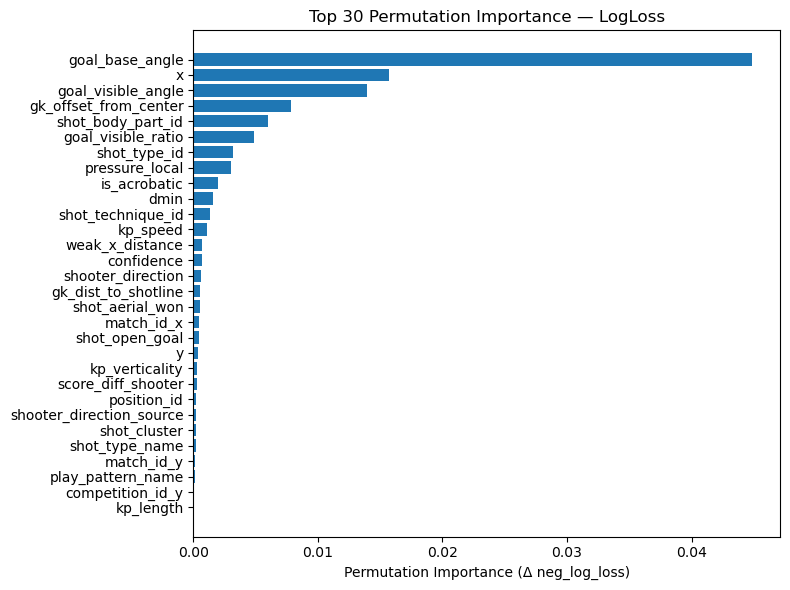

(                     feature      imp_mean   imp_std
 0            goal_base_angle  4.485809e-02  0.002038
 1                          x  1.573988e-02  0.000767
 2         goal_visible_angle  1.397482e-02  0.000989
 3      gk_offset_from_center  7.810153e-03  0.000890
 4          shot_body_part_id  5.974555e-03  0.000839
 5         goal_visible_ratio  4.904875e-03  0.000615
 6               shot_type_id  3.160645e-03  0.000290
 7             pressure_local  3.000857e-03  0.000685
 8               is_acrobatic  1.983724e-03  0.000355
 9                       dmin  1.541084e-03  0.000364
 10         shot_technique_id  1.318464e-03  0.000263
 11                  kp_speed  1.084713e-03  0.000318
 12           weak_x_distance  6.695496e-04  0.000559
 13                confidence  6.645249e-04  0.000423
 14         shooter_direction  6.058158e-04  0.000296
 15       gk_dist_to_shotline  5.263969e-04  0.000336
 16           shot_aerial_won  5.182511e-04  0.000185
 17                match_id_

In [16]:
# Refit of the model with **BASE + G_ext** and setup variables used by Feature Importance / Permutation Importance cells.

import matplotlib.pyplot as plt

feature_cols   = BASE + G_ext
cat_cols_used  = [c for c in feature_cols if c in cat_cols]
num_cols_used  = [c for c in feature_cols if c in num_cols]

Xb = df_model[feature_cols]
y  = (df_model["shot_outcome_name"] == "Goal").astype(int).to_numpy()

# Split
try:
    _ = tr, te
except NameError:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    tr, te = next(skf.split(Xb, y))

# Preprocessor + Model
pre  = make_preprocessor(cat_cols_used, num_cols_used, rare_min=50)
pipe = Pipeline([
    ("prep", pre),
    ("clf", make_model(123))
])

# Fit
pipe.fit(Xb.iloc[tr], y[tr])

# Sanity check: are the G_exts actually in the numeric block?
num_block_cols = []
for name, trans, cols in pipe.named_steps["prep"].transformers_:
    if name == "num":
        num_block_cols = list(cols)
        break

missing_gext = [c for c in G_ext if c not in num_block_cols]
print(f"Tot feature usate: {len(feature_cols)}  |  num: {len(num_block_cols)}  cat: {len(cat_cols_used)}")
print("G_ext mancanti nel blocco numerico:", missing_gext[:10], ("..." if len(missing_gext)>10 else ""))

# Permutation Feature Importance

from sklearn.inspection import permutation_importance

# Choose X and y of the used fold (reuse tr/te if they are in memory)
if 'feature_cols' in globals():
    feature_cols = feature_cols
elif 'BASE' in globals() and 'G_ext' in globals():
    feature_cols = BASE + G_ext
else:
    feature_cols = cols_base  # fallback

X_all = df_model[feature_cols]
y_all = (df_model["shot_outcome_name"]=="Goal").astype(int).to_numpy()

# If there are already tr/te StratifiedKFold, use them; otherwise create a quick split
try:
    _ = tr, te
except NameError:
    from sklearn.model_selection import StratifiedKFold
    skf_tmp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    tr, te = next(skf_tmp.split(X_all, y_all))

X_te = X_all.iloc[te]
y_te = y_all[te]

# Executes permutation importance ---
# Scoring 1: neg_log_loss
res_ll = permutation_importance(
    estimator=pipe,
    X=X_te,
    y=y_te,
    n_repeats=10,
    scoring='neg_log_loss',
    random_state=42,
    n_jobs=-1
)

# Scoring 2: roc_auc
res_auc = permutation_importance(
    estimator=pipe,
    X=X_te,
    y=y_te,
    n_repeats=10,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

# Builds tables
pi_ll = pd.DataFrame({
    'feature': feature_cols,
    'imp_mean': res_ll.importances_mean,
    'imp_std': res_ll.importances_std
}).sort_values('imp_mean', ascending=False).reset_index(drop=True)

pi_auc = pd.DataFrame({
    'feature': feature_cols,
    'imp_mean': res_auc.importances_mean,
    'imp_std': res_auc.importances_std
}).sort_values('imp_mean', ascending=False).reset_index(drop=True)

print("Top 51 (neg_log_loss):")
print(pi_ll.head(51).to_string(index=False))
print("\nTop 51 (roc_auc):")
print(pi_auc.head(51).to_string(index=False))

# --- Plot (logloss) ---
TopN = 30
plt.figure(figsize=(8, 6))
sub = pi_ll.head(TopN)[::-1]
plt.barh(sub['feature'], sub['imp_mean'])
plt.xlabel('Permutation Importance (Δ neg_log_loss)')
plt.title('Top 30 Permutation Importance — LogLoss')
plt.tight_layout()
plt.show()

# Complete outputs
pi_ll, pi_auc



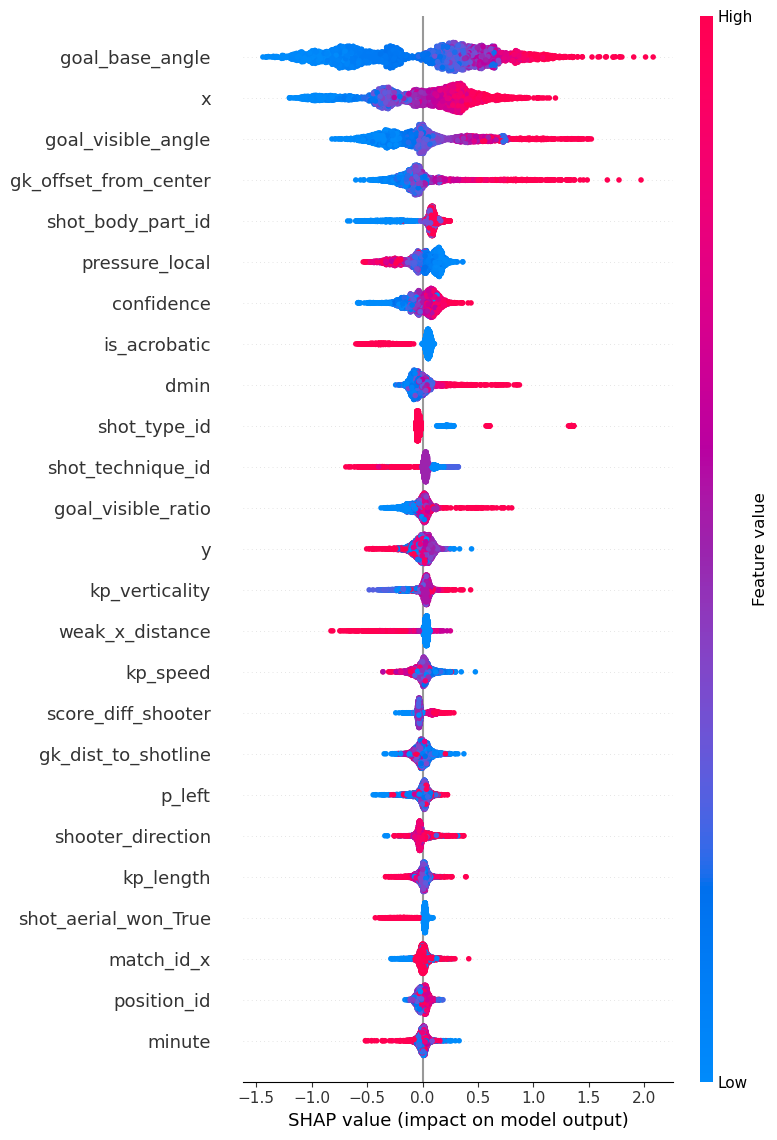

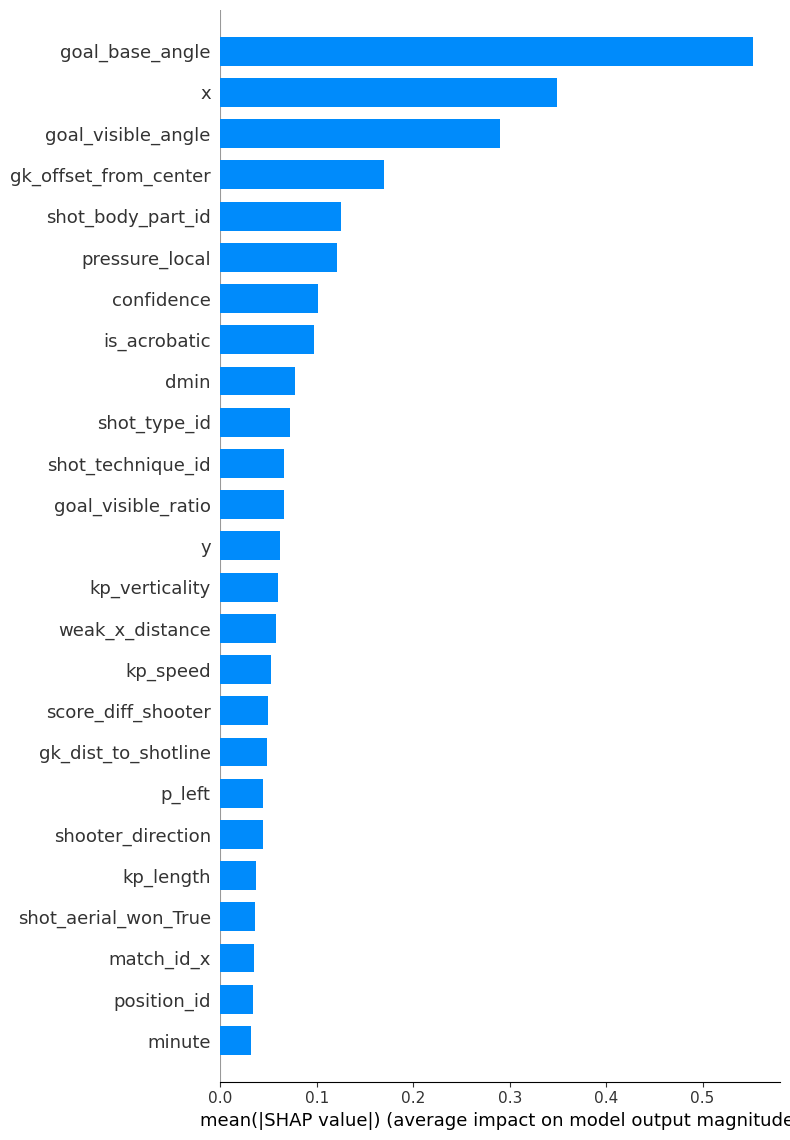

In [ ]:
# --- SHAP ---

import numpy as np
import shap
from scipy import sparse

# Extracts preprocessor and model from the pipeline
pre = final_pipe.named_steps["prep"]
clf = final_pipe.named_steps["clf"]

# Sample a subset (SHAP can be expensive)
SHAP_SAMPLE = 4000
rs = np.random.RandomState(42)
idx = rs.choice(len(X), size=min(SHAP_SAMPLE, len(X)), replace=False)

X_shap_raw = X.iloc[idx]
X_shap = pre.transform(X_shap_raw)

# Converts to dense (avoid indexing issues with scipy sparse)
if sparse.issparse(X_shap):
    X_shap_dense = X_shap.toarray()
else:
    X_shap_dense = np.asarray(X_shap)

# Feature names post-preprocessing
feature_names = ct_feature_names(pre)

# SHAP exectution
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap_dense)

# Robustly select the "goal" class
# - shap_values ​​can be:
# a) list [class0, class1]
# b) 2D array (n_samples, n_features)
# c) 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_goal = shap_values[1]  # classe 1 = goal
else:
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_goal = shap_values[:, :, 1]
    else:
        shap_goal = shap_values  # già 2D

# Plot
shap.summary_plot(
    shap_goal,
    X_shap_dense,
    feature_names=feature_names,
    max_display=25,
    show=True
)

shap.summary_plot(
    shap_goal,
    X_shap_dense,
    feature_names=feature_names,
    plot_type="bar",
    max_display=25,
    show=True
)


In [ ]:
# ==== 5-fold CV: Base vs Isotonic (OOF) ====
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

X = df_model[feature_cols]
y = (df_model["shot_outcome_name"] == "Goal").astype(int).to_numpy()

def strip_monotone_constraints(pipe):
    params = pipe.get_params(deep=True)
    keys = [k for k in params if k.endswith("monotone_constraints")]
    pipe2 = clone(pipe)
    if keys:
        pipe2.set_params(**{k: None for k in keys})
    return pipe2

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

p_base_oof = np.empty_like(y, dtype=float); p_base_oof[:] = np.nan
p_cal_oof  = np.empty_like(y, dtype=float); p_cal_oof[:]  = np.nan

fold_metrics_base, fold_metrics_cal = [], []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = list(skf.split(X, y))

for fold, (tr, te) in enumerate(folds, 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y[tr], y[te]

    # Base
    base = clone(final_pipe)
    base.fit(X_tr, y_tr)
    p_te_base = base.predict_proba(X_te)[:, 1]
    p_base_oof[te] = p_te_base
    fold_metrics_base.append(metrics(y_te, p_te_base))

    # Calibrated (isotonic)
    est_for_cal = clone(final_pipe)
    cal = CalibratedClassifierCV(estimator=est_for_cal, method="isotonic", cv=5)
    cal.fit(X_tr, y_tr)
    p_te_cal = cal.predict_proba(X_te)[:, 1]
    p_cal_oof[te] = p_te_cal
    fold_metrics_cal.append(metrics(y_te, p_te_cal))

# CV Summary (media e std sui fold)
mean_metrics_base = {k: float(np.mean([m[k] for m in fold_metrics_base])) for k in fold_metrics_base[0]}
std_metrics_base  = {k: float(np.std( [m[k] for m in fold_metrics_base])) for k in fold_metrics_base[0]}
mean_metrics_cal  = {k: float(np.mean([m[k] for m in fold_metrics_cal]))  for k in fold_metrics_cal[0]}
std_metrics_cal   = {k: float(np.std( [m[k] for m in fold_metrics_cal]))  for k in fold_metrics_cal[0]}

print("CV mean (Base):", mean_metrics_base)
print("CV std  (Base):", std_metrics_base)
print("CV mean (Iso): ", mean_metrics_cal)
print("CV std  (Iso): ", std_metrics_cal)

# Global OOF metrics (a single estimate across the entire dataset)
oof_base = metrics(y, p_base_oof)
oof_cal  = metrics(y, p_cal_oof)
print("\nOOF Base:", oof_base)
print("OOF Iso :", oof_cal)


CV mean (Base): {'logloss': 0.262034585012337, 'brier': 0.07507715559698255, 'roc_auc': 0.830108679782618, 'avg_precision': 0.4873091373026055, 'accuracy': 0.9051725288660482, 'precision_macro': 0.8069941172465128, 'recall_macro': 0.6187660195894829, 'f1_macro': 0.658967656967804, 'precision_weighted': 0.8901070811501762, 'recall_weighted': 0.9051725288660482, 'f1_weighted': 0.8846247716162813, 'f1_micro': 0.9051725288660482, 'precision_goal': 0.7002688249070964, 'recall_goal': 0.25099490191482127, 'f1_goal': 0.36920398359289, 'precision_nogoal': 0.9137194095859293, 'recall_nogoal': 0.9865371372641445, 'f1_nogoal': 0.9487313303427181, 'TP (goal)': 416.0, 'FP': 179.4, 'FN': 1241.4, 'TN': 13146.2, 'goal_rate_true': 0.11061870119468731, 'goal_rate_pred': 0.03973837015283989, 'total_samples': 14983.0}
CV std  (Base): {'logloss': 0.0044309335685467225, 'brier': 0.0012203921381686066, 'roc_auc': 0.006617309591402134, 'avg_precision': 0.01362995649947636, 'accuracy': 0.0014703922717989825, 'p

In [ ]:
# ==== 5-fold CV: Base OOF + Calibrazione su OOF ====
from sklearn.isotonic import IsotonicRegression


X = df_model[feature_cols]
y = (df_model["shot_outcome_name"] == "Goal").astype(int).to_numpy()

def strip_monotone_constraints(pipe):
    params = pipe.get_params(deep=True)
    keys = [k for k in params if k.endswith("monotone_constraints")]
    pipe2 = clone(pipe)
    if keys:
        pipe2.set_params(**{k: None for k in keys})
    return pipe2

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) base model OOF (no calibration)
p_base_oof = np.empty_like(y, dtype=float); p_base_oof[:] = np.nan
fold_metrics_base = []

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y[tr], y[te]

    base = strip_monotone_constraints(final_pipe)
    base.fit(X_tr, y_tr)
    p_te_base = base.predict_proba(X_te)[:, 1]
    p_base_oof[te] = p_te_base
    fold_metrics_base.append(metrics(y_te, p_te_base))

# 2) Single calibration on OOF
# -- Isotonic
iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
iso.fit(p_base_oof, y)
p_cal_oof_iso = iso.transform(p_base_oof)

# 3) Report
mean_metrics_base = {k: float(np.mean([m[k] for m in fold_metrics_base])) for k in fold_metrics_base[0]}
std_metrics_base  = {k: float(np.std( [m[k] for m in fold_metrics_base])) for k in fold_metrics_base[0]}
print("CV mean (Base):", mean_metrics_base)
print("CV std  (Base):",  std_metrics_base)

oof_base  = metrics(y, p_base_oof)
oof_iso   = metrics(y, p_cal_oof_iso)

print("\nOOF Base :", oof_base)
print("OOF Iso  :", oof_iso)


CV mean (Base): {'logloss': 0.262034585012337, 'brier': 0.07507715559698255, 'roc_auc': 0.830108679782618, 'avg_precision': 0.4873091373026055, 'accuracy': 0.9051725288660482, 'precision_macro': 0.8069941172465128, 'recall_macro': 0.6187660195894829, 'f1_macro': 0.658967656967804, 'precision_weighted': 0.8901070811501762, 'recall_weighted': 0.9051725288660482, 'f1_weighted': 0.8846247716162813, 'f1_micro': 0.9051725288660482, 'precision_goal': 0.7002688249070964, 'recall_goal': 0.25099490191482127, 'f1_goal': 0.36920398359289, 'precision_nogoal': 0.9137194095859293, 'recall_nogoal': 0.9865371372641445, 'f1_nogoal': 0.9487313303427181, 'TP (goal)': 416.0, 'FP': 179.4, 'FN': 1241.4, 'TN': 13146.2, 'goal_rate_true': 0.11061870119468731, 'goal_rate_pred': 0.03973837015283989, 'total_samples': 14983.0}
CV std  (Base): {'logloss': 0.0044309335685467225, 'brier': 0.0012203921381686066, 'roc_auc': 0.006617309591402134, 'avg_precision': 0.01362995649947636, 'accuracy': 0.0014703922717989825, 'p

In [ ]:

from sklearn.model_selection import GroupKFold

# --- INPUT ---
# df_model: complete shot dataframe
# y: binary target (1=goal, 0=no goal)
# X: features used by final_pipe
# final_pipe: complete pipeline (preprocess + clf)
# groups: to avoid leakage between related events.

X = df_model[feature_cols]                 
y = (df_model["shot_outcome_name"]=="Goal").astype(int).to_numpy()
groups = df_model["match_id"]             

# --- CV choice ---
# AVOID leakage between events of the same match:
cv = GroupKFold(n_splits=5)

oof = np.full(len(df_model), np.nan, dtype=float)
models = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[va_idx], y[va_idx]

    pipe = clone(final_pipe)          
    pipe.fit(X_tr, y_tr)              
    p_va = pipe.predict_proba(X_va)[:, 1]  

    oof[va_idx] = p_va
    models.append(pipe)
    

# Check
assert np.isfinite(oof).all(), "Ci sono NaN nelle OOF: controlla lo split."


df_model["xG_oof"] = oof


df_model.to_parquet("data/xg_dataset_oof.parquet", index=False)


In [21]:
n_matches = df_model["match_id_x"].nunique()
print("Numero totale di match nel dataset:", n_matches)


Numero totale di match nel dataset: 2960


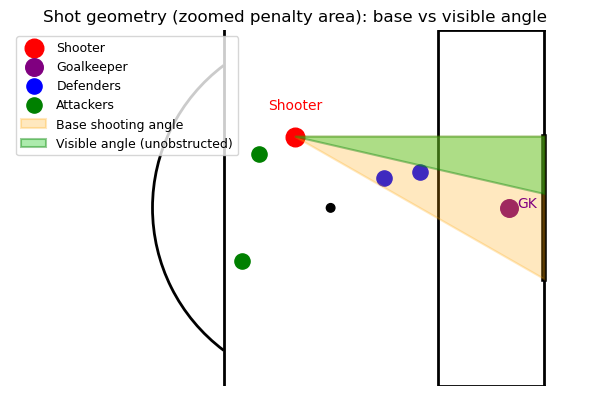

In [ ]:
from mplsoccer import Pitch
from matplotlib.patches import Polygon

# random coordinates
shooter = np.array([106, 44])      
goal_left = np.array([120, 36])
goal_right = np.array([120, 44])
goal_center = np.array([120, 40])

# defenders
defenders = np.array([
    [113, 42],
    [111, 41.7],
])

# goalkeeper
gk = np.array([118, 40])

# attackers
attackers = np.array([
    [103, 37],
    [104, 43],
])

# Visible angle functions
def angle_from_shooter(point):
    v = point - shooter
    return np.degrees(np.arctan2(v[1], v[0]))

base_left = angle_from_shooter(goal_left)
base_right = angle_from_shooter(goal_right)

def_angles = np.array([angle_from_shooter(d) for d in defenders])
in_cone = (def_angles >= base_left) & (def_angles <= base_right)
def_in_cone = def_angles[in_cone]

delta = 3
if len(def_in_cone) > 0:
    amin = def_in_cone.min()
    amax = def_in_cone.max()
    blocked_start = max(base_left, amin - delta)
    blocked_end   = min(base_right, amax + delta)
else:
    blocked_start, blocked_end = None, None

if blocked_start is not None and blocked_end is not None:
    gap1 = (base_left, blocked_start, blocked_start - base_left)
    gap2 = (blocked_end, base_right, base_right - blocked_end)
    visible_left, visible_right = (gap1[0], gap1[1]) if gap1[2] > gap2[2] else (gap2[0], gap2[1])
else:
    visible_left, visible_right = base_left, base_right

GOAL_X = 120.0  # goal line in StatsBomb coordinates

def ray_to_goal_line(theta_deg, x_goal=GOAL_X):
    """Intersection between ray from shooter at angle theta and vertical line x=x_goal."""
    theta = np.deg2rad(theta_deg)
    dx = np.cos(theta)
    dy = np.sin(theta)

    # avoid division by zero (shouldn't happen here because goal is to the right)
    if abs(dx) < 1e-9:
        return np.array([x_goal, shooter[1]])

    t = (x_goal - shooter[0]) / dx
    y = shooter[1] + t * dy
    return np.array([x_goal, y])

# Endpoints on goal line for base and visible angles
p_base_L = ray_to_goal_line(base_left)
p_base_R = ray_to_goal_line(base_right)

p_vis_L = ray_to_goal_line(visible_left)
p_vis_R = ray_to_goal_line(visible_right)

# Field + Zoom
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(6, 5))

# Points
pitch.scatter(shooter[0], shooter[1], ax=ax, color='red', s=180, label="Shooter")
pitch.scatter(gk[0], gk[1], ax=ax, color='purple', s=160, label="Goalkeeper")
pitch.scatter(defenders[:, 0], defenders[:, 1], ax=ax, color='blue', s=120, label="Defenders")
pitch.scatter(attackers[:, 0], attackers[:, 1], ax=ax, color='green', s=120, label="Attackers")

# --- Base angle polygon (clipped to goal line) ---
poly_base = Polygon(
    [shooter, p_base_L, p_base_R],
    closed=True, facecolor='orange', alpha=0.25,
    edgecolor='orange', lw=1.5, label="Base shooting angle"
)
ax.add_patch(poly_base)

# --- Visible angle polygon (clipped to goal line) ---
poly_visible = Polygon(
    [shooter, p_vis_L, p_vis_R],
    closed=True, facecolor='limegreen', alpha=0.40,
    edgecolor='green', lw=1.5, label="Visible angle (unobstructed)"
)
ax.add_patch(poly_visible)

# Labels + zoom
ax.text(shooter[0] - 1.5, shooter[1] + 1.5, "Shooter", color="red")
ax.text(gk[0] + 0.5, gk[1], "GK", color="purple")

ax.set_xlim(90, 122)
ax.set_ylim(30, 50)

ax.set_title("Shot geometry (zoomed penalty area): base vs visible angle", fontsize=12)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
fig.savefig("shot_geometry_angles.pdf", format="pdf", bbox_inches="tight")
plt.show()

